# DDM: a stationary source, an absorbing decision bound

Parts 1-2 (`01_beads.ipynb`, `02_triangles.ipynb`) tracked a source that keeps switching forever, with a *stabilizing*, non-absorbing bound. The standard drift-diffusion model (DDM) used in accumulate-to-bound decision tasks is the opposite regime: a **stationary** source (no hazard, no switching within a trial) and an **absorbing** bound — the accumulator runs until it hits one of two decision bounds, and hitting the bound *is* the response.

This notebook asks the same question as `01_beads.ipynb`/`02_triangles.ipynb` — what does a capacity limit do to the accumulation process? — in this different structural regime, in three parts: **foundations** (building up the absorbing-bound analog of the IB derivation, from a uniform chain through fully honest, prior-uncertain optimal placement), **single-decision dynamics** (what capacity-limited accumulation looks like on one trial), and **testable predictions**. General IB theory is in `00_overview.ipynb`.

The foundations section below is substantial — it consolidates what were originally three separate derivation notebooks (a uniform-ladder baseline, an oracle known-drift optimal placement, and the honest unknown-drift placement that turned out to overturn the oracle's headline result) into one build-up, in the order they were actually derived, since each part's motivation depends on what the previous part found.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "utilities"))

import itertools
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from absorbing_ib import (
    walk_params_from_ddm, k_min_for_validity, build_absorbing_chain,
    exact_absorption_stats, exact_rt_distribution, simulate_discrete_chain,
    simulate_ddm, ddm_analytic_accuracy, ddm_analytic_mean_rt, capacity_frontier,
    simulate_ddm as simulate_ddm_trials,
)
from ib_optimal_placement import (
    relevance, fine_reference, optimal_partition, uniform_partition_boundaries,
    objective_of_boundaries, group_centroids, find_start_group,
    nonuniform_ctmc_rates, build_birth_death, nonuniform_chain_stats,
    simulate_nonuniform_chain, ib_optimal_chain, ib_optimal_chain_fixed_start,
    optimal_partition_fixed_start, uniform_partition_boundaries_fixed_start,
)
from ib_optimal_placement_unknown_drift import (
    prior_relevance, mixture_fine_reference, mixture_chain_stats, mixture_simulate,
    ib_optimal_chain_unknown_drift, ib_optimal_chain_unknown_drift_fixed_start,
    snr_branches, mixture_fine_reference_multi, mixture_chain_stats_multi,
    mixture_simulate_multi, ib_optimal_chain_snr_range_fixed_start,
)
from intuitions import (
    simulate_ddm_path, simulate_discrete_chain_path, simulate_nonuniform_chain_path,
    quantize_ddm_path,
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "figure.titlesize": 13,
})

NORM_COLOR = "#2b6cb0"
LADDER_COLORS = {2: "#c53030", 4: "#dd6b20", 8: "#d69e2e"}
SHADE_COLOR = "#ebf4ff"

# Same example DDM throughout: moderate drift, unit noise, bound separation 2, unbiased start.
v, s, a, z_frac = 0.6, 1.0, 2.0, 0.5
v0 = v  # Part C below builds encoders that know only |v|, not its sign -- v0 is that magnitude
k0 = 300  # fine reference resolution used throughout Parts B-C
print(f"DDM: v={v}, s={s}, a={a}, z_frac={z_frac}")

DDM: v=0.6, s=1.0, a=2.0, z_frac=0.5


## 1. Foundations, Part A: the uniform absorbing chain

A discrete-time, discrete-state random walk with absorbing barriers converges to the DDM as the number of interior states grows and step size shrinks to match (Feller 1968; Ratcliff's 1978 original derivation of the diffusion model is exactly this, as the continuum limit of a random-walk model). That convergence parameter — how many discrete, distinguishable states of accumulated evidence the walk is allowed between the bounds — is exactly a *capacity* in the sense `01_beads.ipynb` uses the term. Fixing the physical decision bound `a`, drift `v`, and noise `s` and asking what happens as the number of interior states `k` shrinks is the absorbing-bound analog of that notebook's central question.

This part builds the chain and solves it exactly, matches it to a target continuous DDM (deriving a capacity floor, the absorbing-bound analog of `01_beads.ipynb`'s `beta_c`), sweeps capacity to show convergence, and shows a first behavioral signature (RT-distribution banding). It uses a **uniform**, evenly-spaced ladder throughout — deliberately not yet the information-optimal placement Parts B-C derive.


### 1.1. The discrete chain

States `0, 1, ..., k` on the belief axis. States `0` and `k` are absorbing —
reaching one *is* the choice. States `1, ..., k-1` are transient: an
evidence token moves the state up one rung with probability `p`, down one
rung with probability `1-p` (an ordered chain with uniform step size, the
absorbing-bound counterpart of the beads notebook's non-absorbing "bounded ladder,"
§6, Figure 5c).

For a small, concrete example: `k = 4` (three transient states, `1, 2, 3`),
with an up-probability `p = 0.65` (evidence favors the upper/correct bound).


In [2]:

k_demo, p_demo = 4, 0.65
Q, R, transient_states = build_absorbing_chain(k_demo, p_demo)

print("transient states:", transient_states)
print("\nQ (transient -> transient):\n", np.round(Q, 3))
print("\nR (transient -> [absorb-lower, absorb-upper]):\n", np.round(R, 3))


transient states: [1 2 3]

Q (transient -> transient):
 [[0.   0.65 0.  ]
 [0.35 0.   0.65]
 [0.   0.35 0.  ]]

R (transient -> [absorb-lower, absorb-upper]):
 [[0.35 0.  ]
 [0.   0.  ]
 [0.   0.65]]



#### 1.1.1. Exact solution via the fundamental matrix

For an absorbing Markov chain with transient block `Q` and
transient-to-absorbing block `R`, the fundamental matrix
`N = (I - Q)^-1` gives, in one linear solve and with no simulation:

- `N @ 1` — expected number of steps to absorption from each transient state
- `N @ R` — the probability of ending at each absorbing state from each transient state

This is exact linear algebra, in the same spirit as the beads notebook's exact
Blahut-Arimoto / HMM-recursion computations (never Monte Carlo where an
exact answer is available). Simulation below is used only to *validate* it.


In [3]:

z0_index = 1  # start at transient state '2' (the middle rung, 0-based index into [1,2,3])
stats = exact_absorption_stats(Q, R, z0_index)
print(f"starting at state {transient_states[z0_index]} of 0..{k_demo}")
print(f"  P(absorb lower)  = {stats['p_lower']:.4f}")
print(f"  P(absorb upper)  = {stats['p_upper']:.4f}")
print(f"  E[steps to absorb] = {stats['expected_steps']:.4f}")

# validate against direct simulation of the same discrete chain
steps_sim, choice_sim = simulate_discrete_chain(k_demo, p_demo, z0_index,
                                                 n_trials=200_000, n_max=500, seed=0)
print(f"\nsimulated: P(upper) = {np.nanmean(choice_sim):.4f}, "
      f"E[steps] = {np.nanmean(steps_sim):.4f}  (200,000 trials)")


starting at state 2 of 0..4
  P(absorb lower)  = 0.2248
  P(absorb upper)  = 0.7752
  E[steps to absorb] = 3.6697

simulated: P(upper) = 0.7726, E[steps] = 3.6630  (200,000 trials)



### 1.2. Matching the chain to a continuous DDM, and a capacity floor

`walk_params_from_ddm(v, s, a, k)` implements the classical random-walk ->
diffusion correspondence: fix the bound separation `a`, drift `v`, and noise
`s` (i.e. fix the task and the observer's sensitivity to it, exactly as a
standard DDM fit would), pick a capacity `k` (number of interior rungs), and
the step size `eps = a/k` and step duration `tau` and up-probability `p` are
then *determined* — not free parameters. Larger `k` means smaller, faster,
individually-less-informative steps; smaller `k` means fewer, larger, more
informative-looking single steps.

That "more informative per step" property is exactly why very small `k`
breaks the correspondence: `p = 0.5*(1 + v*a / (k*s^2))` must stay in
`(0, 1)`, which requires

    k > k_min = |v| * a / s^2

Below `k_min` a single step would need to carry more evidence than the
entire bound separation allows for the diffusion match to remain a valid
probability. This is the absorbing-bound analog of the beads notebook's `beta_c`
(`01_beads.ipynb` §1.5): a hard floor on how coarse the representation can be before the
construction itself stops making sense, not just a floor on how well it
performs.


In [4]:

v, s, a = 0.6, 1.0, 2.0   # example DDM: moderate drift, unit noise, bound separation 2
kmin = k_min_for_validity(v, s, a)
print(f"DDM params: v={v}, s={s}, a={a}  ->  k_min = {kmin:.3f}")

print(f"\n{'k':>5} {'p':>8} {'tau':>10} {'eps':>8}")
for k in [2, 3, 5, 10, 30, 100]:
    wp = walk_params_from_ddm(v, s, a, k)
    flag = "" if 0 < wp['p'] < 1 else "  <- invalid (k <= k_min)"
    print(f"{k:5d} {wp['p']:8.4f} {wp['tau']:10.5f} {wp['eps']:8.4f}{flag}")


DDM params: v=0.6, s=1.0, a=2.0  ->  k_min = 1.200

    k        p        tau      eps
    2   0.8000    1.00000   1.0000
    3   0.7000    0.44444   0.6667
    5   0.6200    0.16000   0.4000
   10   0.5600    0.04000   0.2000
   30   0.5200    0.00444   0.0667
  100   0.5060    0.00040   0.0200



### 1.3. Convergence to the continuous DDM as capacity grows

Sweep `k` (holding `v`, `s`, `a` fixed — i.e. holding the task and the
observer's raw sensitivity fixed, varying only representational capacity)
and compute the *exact* accuracy and mean RT at each `k`. These should
converge onto the continuous DDM's closed-form values (computed
independently via the hitting-time ODE, and cross-checked against direct
Euler-Maruyama simulation of the continuous process) as `k -> infinity`.


In [5]:

z_frac = 0.5  # unbiased start
k_list = np.unique(np.round(np.geomspace(2, 800, 60)).astype(int))
frontier = capacity_frontier(k_list, v, s, a, z_frac=z_frac)

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

rt_sim, ch_sim = simulate_ddm(v, s, a, z_frac, dt=1e-3, n_trials=40_000, t_max=30, seed=0)
print(f"continuous DDM, analytic:   accuracy = {acc_inf:.4f}, mean RT = {rt_inf:.4f}")
print(f"continuous DDM, simulated:  accuracy = {np.nanmean(ch_sim):.4f}, "
      f"mean RT = {np.nanmean(rt_sim):.4f}  (40,000 trials, dt=1e-3)")


continuous DDM, analytic:   accuracy = 0.7685, mean RT = 0.8951
continuous DDM, simulated:  accuracy = 0.7740, mean RT = 0.9292  (40,000 trials, dt=1e-3)


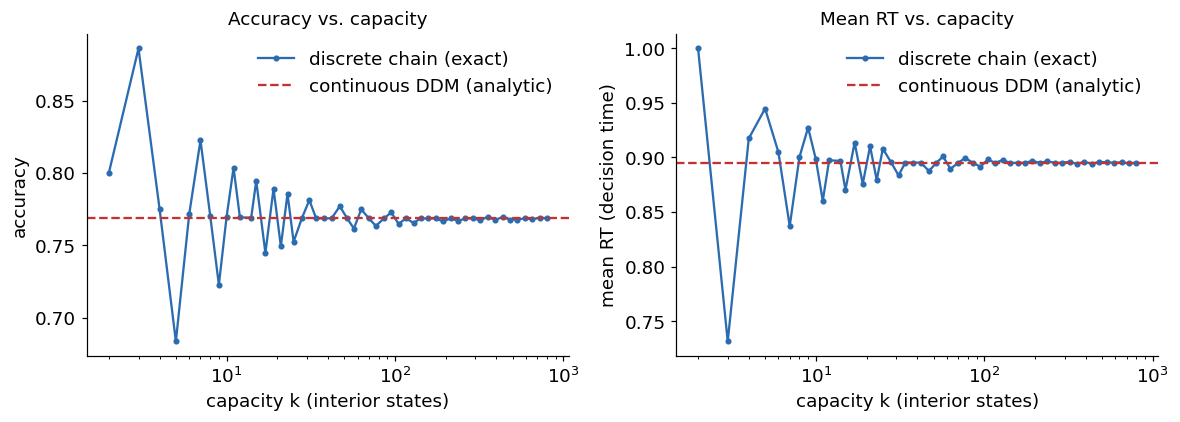

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(frontier['k'], frontier['accuracy'], 'o-', ms=3, color='#2b6cb0', label='discrete chain (exact)')
ax.axhline(acc_inf, color='#c53030', ls='--', label='continuous DDM (analytic)')
ax.set_xscale('log')
ax.set_xlabel('capacity k (interior states)')
ax.set_ylabel('accuracy')
ax.set_title('Accuracy vs. capacity')
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(frontier['k'], frontier['mean_rt'], 'o-', ms=3, color='#2b6cb0', label='discrete chain (exact)')
ax.axhline(rt_inf, color='#c53030', ls='--', label='continuous DDM (analytic)')
ax.set_xscale('log')
ax.set_xlabel('capacity k (interior states)')
ax.set_ylabel('mean RT (decision time)')
ax.set_title('Mean RT vs. capacity')
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
plt.show()



Both curves converge cleanly onto the continuous DDM's values as `k` grows,
which validates the construction — this is the expected, known limit, and
recovering it exactly is the sanity check, not the finding.

The finding is in the *approach*: it is not a smooth, monotonic shrinkage
toward the continuous values. At small `k` there is visible non-monotonic
structure — particular `k` values do noticeably better or worse than their
neighbors, because how the bound separation divides into `k` rungs
determines whether the (fixed) start point lands near the middle of a rung
or near a boundary between rungs, a discreteness/parity effect with no
analog in the continuous model. This is the same qualitative lesson as the
memo's own staircase frontier (Figure 2a) and uneven branch structure
(§2.2): capacity-limited performance is not a smooth rescaling of the
unconstrained solution, and shouldn't be modeled as one.



### 1.4. RT-distribution shape: the behavioral signature of low capacity

A capacity cut changes more than mean RT and accuracy — it changes the
*shape* of the RT distribution. With few rungs, only a few distinct step
counts are possible before absorption, so the RT distribution should show
visible banding/discreteness at low `k`, smoothing into the familiar
right-skewed continuous shape as `k` grows. This is a candidate behavioral
signature in the same spirit as the beads notebook's confidence-report prediction
(`01_beads.ipynb` §3.1): something a standard-DDM fit doesn't have a reason to produce, that
a capacity account does.

`exact_rt_distribution` gets the full distribution over step counts exactly
(no simulation) via the same fundamental-matrix machinery, propagated one
step at a time.


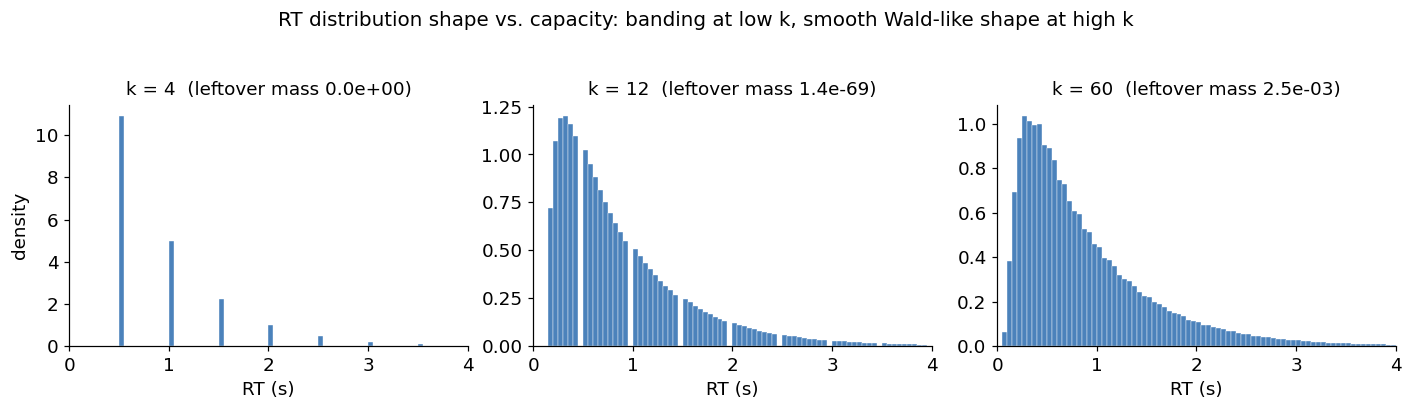

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=False)

for ax, k in zip(axes, [4, 12, 60]):
    wp = walk_params_from_ddm(v, s, a, k)
    z0 = int(np.clip(round(z_frac * k), 1, k - 1)) - 1
    Qk, Rk, _ = build_absorbing_chain(k, wp['p'])
    n_max = 4000
    hits, leftover = exact_rt_distribution(Qk, Rk, z0, n_max=n_max)
    rt_axis = np.arange(1, n_max + 1) * wp['tau']
    total = hits.sum(1)  # P(absorbed at step n), either boundary

    # bin into a fixed real-time grid so different k are comparable
    bins = np.linspace(0, 4, 81)
    dig = np.digitize(rt_axis, bins) - 1
    density = np.zeros(len(bins) - 1)
    for b, m in zip(dig, total):
        if 0 <= b < len(density):
            density[b] += m
    density /= (bins[1] - bins[0])

    ax.bar(bins[:-1], density, width=bins[1] - bins[0], align='edge',
           color='#2b6cb0', alpha=0.85, edgecolor='white', linewidth=0.3)
    ax.set_title(f'k = {k}  (leftover mass {leftover:.1e})')
    ax.set_xlabel('RT (s)')
    ax.set_xlim(0, 4)

axes[0].set_ylabel('density')
fig.suptitle('RT distribution shape vs. capacity: banding at low k, smooth Wald-like shape at high k', y=1.03)
fig.tight_layout()
plt.show()


### 1.5. Validation summary

- **Exact discrete-chain solution vs. simulation of the same chain** — confirms the fundamental-matrix algebra.
- **Large-k discrete chain vs. Euler-Maruyama simulation of the continuous DDM** — confirms the random-walk/diffusion correspondence, independent of the analytic hitting-time formulas.


In [8]:

# 1. exact vs. simulated discrete chain, at a middling k
k_val, p_val = 15, walk_params_from_ddm(v, s, a, 15)['p']
z0 = int(np.clip(round(z_frac * k_val), 1, k_val - 1)) - 1
Qc, Rc, _ = build_absorbing_chain(k_val, p_val)
exact = exact_absorption_stats(Qc, Rc, z0)
steps_sim, ch_sim = simulate_discrete_chain(k_val, p_val, z0, n_trials=300_000, n_max=2000, seed=3)
print("discrete chain, k =", k_val)
print(f"  accuracy   exact={exact['p_upper']:.4f}   simulated={np.nanmean(ch_sim):.4f}")
print(f"  E[steps]   exact={exact['expected_steps']:.4f}   simulated={np.nanmean(steps_sim):.4f}")

# 2. large-k discrete chain vs. simulated continuous DDM
k_big = 400
wp_big = walk_params_from_ddm(v, s, a, k_big)
z0b = int(np.clip(round(z_frac * k_big), 1, k_big - 1)) - 1
Qb, Rb, _ = build_absorbing_chain(k_big, wp_big['p'])
exact_big = exact_absorption_stats(Qb, Rb, z0b)
rt_cont, ch_cont = simulate_ddm(v, s, a, z_frac, dt=1e-3, n_trials=40_000, t_max=30, seed=4)
print(f"\ndiscrete chain, k = {k_big} (exact):        "
      f"accuracy = {exact_big['p_upper']:.4f}, mean RT = {exact_big['expected_steps']*wp_big['tau']:.4f}")
print(f"continuous DDM (simulated, 40,000 trials):  "
      f"accuracy = {np.nanmean(ch_cont):.4f}, mean RT = {np.nanmean(rt_cont):.4f}")


discrete chain, k = 15
  accuracy   exact=0.7944   simulated=0.7938
  E[steps]   exact=48.9543   simulated=48.9049



discrete chain, k = 400 (exact):        accuracy = 0.7685, mean RT = 0.8951
continuous DDM (simulated, 40,000 trials):  accuracy = 0.7713, mean RT = 0.9312


**Where Part A leaves off.** Established here, exactly and validated: the bead task's non-absorbing bounded ladder and the DDM's absorbing accumulate-to-bound process are two instances of the same underlying question, differing only in the boundary condition; a capacity `k` has a well-defined, exact effect on accuracy and RT, converging to the standard continuous-DDM answer as `k -> infinity`; there's a capacity floor `k_min = |v|a/s^2` below which the correspondence breaks rather than merely degrading; and low capacity leaves a mark on RT-distribution *shape* (banding), not just its mean. Deliberately not done: this chain has uniform step size by construction, not yet the information-optimal placement — the natural next step, in Part B.

## 2. Foundations, Part B: known-drift (oracle) optimal placement

Per `01_beads.ipynb`/`02_triangles.ipynb`, an information-optimal capacity-limited representation is not uniformly spaced — resolution concentrates where *(occupancy) x (usefulness)* peaks, states are unevenly spaced, and capacity **sharpens, then splits** rather than smoothly refining everything at once. This part derives that placement for the absorbing-bound case.

**A scope warning up front, because it matters for how to read every result in this part.** What's derived here is the placement that is optimal *given the trial's actual drift* — sign and magnitude both known when the encoder is built. That is not a realistic capacity-limited observer: if you already knew which way the evidence was going to point, you wouldn't need to accumulate it. What this part actually computes is an **oracle upper bound** — the best any capacity-`k` absorbing encoder could possibly do if told the answer's direction and strength in advance. That's a legitimate and useful quantity — a ceiling to measure a realistic encoder against — but it is not itself a model of a capacity-limited decision-maker. The realistic version (encoder fixed *before* the trial's drift is known) is Part C, which reuses the dynamic-programming and chain-construction machinery here unchanged but replaces the relevance and occupancy calculations with prior-averaged versions.

The right formulation for a terminating accumulator has three exact pieces, none needing simulation to solve: **relevance** `q(x)=P(Y=upper|X_t=x)` (closed form, from the DDM/LLR equivalence via Girsanov); **occupancy** `p(x)` (how much time the process spends at each point before absorption, exact from the fundamental matrix of a fine reference chain, reusing Part A's machinery); and **optimal grouping** (both quantities are monotone along the 1-D accumulator axis, so the IB-optimal quantizer into `k` states is provably an interval partition, solvable *exactly* by dynamic programming — a global optimum, unlike Blahut-Arimoto's local search, and this piece is agnostic to how relevance/occupancy were computed, carrying over unchanged to Part C).


### 2.1. The two ingredients: relevance and occupancy

**Relevance.** In a matched DDM, the position `X_t` is an affine transform of
the accumulated log-likelihood ratio for "drift = +v" vs. "drift = -v": by
Girsanov's theorem, `LLR_t = (2v/s^2) X_t`, with no separate time-dependent
term (the drift-magnitude penalty is identical under both hypotheses and
cancels). So under a symmetric 50/50 prior over which hypothesis is true,

```
q(x) = P(Y=upper | X_t=x) = sigmoid(2v(x - z0)/s^2)
```

exactly, with no free parameters and no need to solve anything — this is
`relevance()` in the new module. It is *not* the same quantity as the
`exact_absorption_stats` "probability of eventually hitting the upper
bound," which is a fact about where the trajectory ends up, not about the
ground truth; `q(x)` is the Bayesian-relevant one for an IB objective.

**Occupancy.** How much time the process spends at each point before
absorption is not closed-form in general, but it doesn't need to be: for a
fine (large-`k0`) *uniform* reference chain, the expected number of visits
to every fine state, starting from `z0`, is exactly one row of the
fundamental matrix `N = (I-Q)^-1` — already computed in Part A above for a
single state at a time; here every entry is read off in one linear solve.
Normalized, this is `P(X=x | still deciding)`.


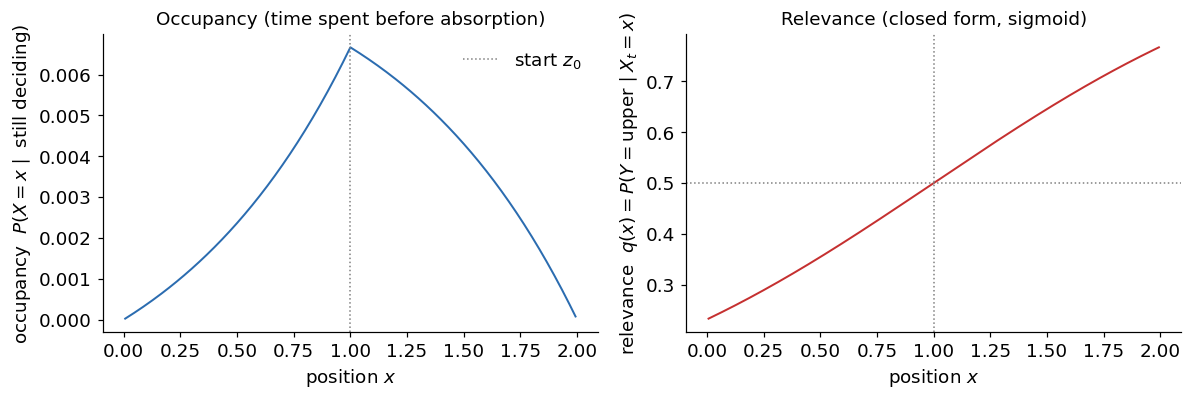

occupancy sums to expected total steps: 1.000000 (normalized to 1 by construction)
relevance range: [0.2329, 0.7671]


In [9]:

k0 = 300  # fine reference resolution
fr = fine_reference(k0, v, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.plot(fr["x"], fr["w"], color="#2b6cb0", lw=1.3)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, label="start $z_0$")
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy  $P(X{=}x \\mid$ still deciding$)$")
ax.set_title("Occupancy (time spent before absorption)")
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(fr["x"], fr["q"], color="#c53030", lw=1.3)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("relevance  $q(x) = P(Y{=}$upper$\\mid X_t{=}x)$")
ax.set_title("Relevance (closed form, sigmoid)")

fig.tight_layout()
plt.show()

print(f"occupancy sums to expected total steps: {fr['w'].sum():.6f} (normalized to 1 by construction)")
print(f"relevance range: [{fr['q'].min():.4f}, {fr['q'].max():.4f}]")



Occupancy is concentrated near the start (the process lingers while
uncertain) and thins out toward the edges (it doesn't spend long near a
boundary before crossing it). Relevance is a sigmoid centered on the start
point, steepest right where the process spends the most time. Their
product — the beads notebook's "occupancy x usefulness" — is what an information-
optimal quantizer should track, and that intuition is now made exact in the
next section rather than left as a heuristic.


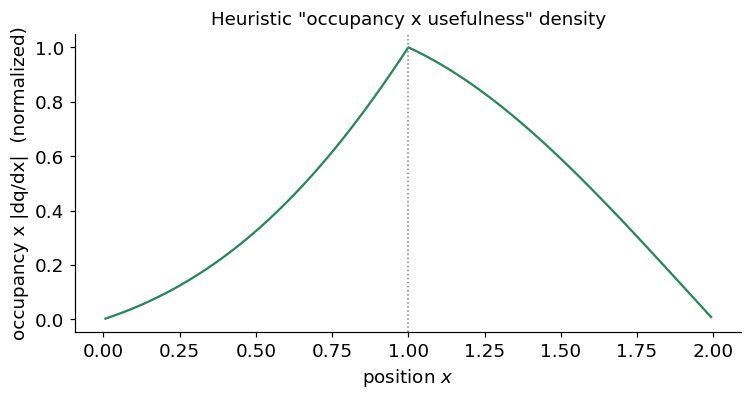

In [10]:

usefulness = np.gradient(fr["q"], fr["x"])  # local slope of q(x): rate at which position resolves Y
product = fr["w"] * np.abs(usefulness)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(fr["x"], product / product.max(), color="#2f855a", lw=1.5)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy x |dq/dx|  (normalized)")
ax.set_title("Heuristic \"occupancy x usefulness\" density")
fig.tight_layout()
plt.show()



### 2.2. Exact optimal placement via dynamic programming

The IB objective for a **hard** quantizer `R = f(X)` (deterministic, so
`I(X;R) = H(R)`) is `I(Y;R) - beta*H(R)`; fixing the number of groups `k`
directly (as Part A above does with its capacity `k`) turns this into
"maximize `I(Y;R)` over partitions into exactly `k` contiguous groups" — no
`beta` needed. Because `q(x)` is monotone in `x` (a scalar, ordered
accumulator axis, unlike the bead task's window-based `x`), the optimal
partition is provably an interval partition: the standard IB solution never
benefits from assigning two states that sandwich a third, more relevant,
state to the same group while excluding the one in between. That means this
can be solved *exactly*, by dynamic programming over interval boundaries,
rather than by Blahut-Arimoto's stochastic soft-assignment search (which
only guarantees a local optimum). `optimal_partition()` implements this in
`O(n^2 k)` using prefix sums for each candidate segment's exact
`I(Y;R)` contribution.


In [11]:

k_groups = 6
boundaries_opt, obj_opt, qbar = optimal_partition(fr["w"], fr["q"], k_groups)
boundaries_unif = uniform_partition_boundaries(len(fr["w"]), k_groups)
obj_unif = objective_of_boundaries(fr["w"], fr["q"], boundaries_unif)

cents_opt = group_centroids(fr["x"], fr["w"], boundaries_opt)
cents_unif = group_centroids(fr["x"], fr["w"], boundaries_unif)

print(f"k = {k_groups} interior rungs, marginal qbar = {qbar:.4f}\n")
print(f"IB-optimal boundaries (fine index): {boundaries_opt}")
print(f"  rung centroids (x):  {np.round(cents_opt, 3)}")
print(f"  I(Y;R) = {obj_opt:.5f} bits\n")
print(f"uniform boundaries (fine index):    {boundaries_unif}")
print(f"  rung centroids (x):  {np.round(cents_unif, 3)}")
print(f"  I(Y;R) = {obj_unif:.5f} bits\n")
print(f"IB-optimal captures {100*(obj_opt/obj_unif - 1):.1f}% more decision-relevant "
      f"information than uniform spacing, at the same capacity k={k_groups}.")


k = 6 interior rungs, marginal qbar = 0.5280

IB-optimal boundaries (fine index): [np.int64(0), np.int64(79), np.int64(123), np.int64(160), np.int64(196), np.int64(236), 299]
  rung centroids (x):  [0.363 0.692 0.953 1.186 1.436 1.724]
  I(Y;R) = 0.03737 bits

uniform boundaries (fine index):    [0, 50, 100, 150, 199, 249, 299]
  rung centroids (x):  [0.228 0.528 0.854 1.16  1.483 1.779]
  I(Y;R) = 0.03692 bits

IB-optimal captures 1.2% more decision-relevant information than uniform spacing, at the same capacity k=6.


In [12]:

# exact global optimum, not just a good local one: brute-force check on a small case
import itertools

k0_small, k_small = 12, 3
fr_small = fine_reference(k0_small, v, s, a, z_frac)
n_small = len(fr_small["w"])
boundaries_dp, obj_dp, _ = optimal_partition(fr_small["w"], fr_small["q"], k_small)

best_bf, best_bounds_bf = -np.inf, None
for combo in itertools.combinations(range(1, n_small), k_small - 1):
    cand = [0] + list(combo) + [n_small]
    val = objective_of_boundaries(fr_small["w"], fr_small["q"], cand)
    if val > best_bf:
        best_bf, best_bounds_bf = val, cand

print(f"DP:           boundaries={boundaries_dp}  I(Y;R)={obj_dp:.6f} bits")
print(f"brute force:  boundaries={best_bounds_bf}  I(Y;R)={best_bf:.6f} bits")
assert np.isclose(obj_dp, best_bf), "DP should recover the brute-force global optimum"
print("\nmatch confirmed: DP finds the exact global optimum, as the monotonicity argument predicts.")


DP:           boundaries=[np.int64(0), np.int64(4), np.int64(7), 11]  I(Y;R)=0.032446 bits
brute force:  boundaries=[0, 4, 7, 11]  I(Y;R)=0.032446 bits

match confirmed: DP finds the exact global optimum, as the monotonicity argument predicts.



### 2.3. From boundaries to a chain: the non-uniform generator

The DP gives group boundaries on the fine reference grid; representing each
group by its occupancy-weighted centroid gives a set of non-uniformly
spaced node positions. To turn that into an actual Markov chain — so exact
accuracy and RT can be computed, not just `I(Y;R)` — transition rates are
built with the standard non-uniform-grid finite-difference discretization
of the diffusion generator `L f = v f' + (s^2/2) f''` (the "Markov chain
approximation method," Kushner & Dupuis 2001): at an interior node with left
spacing `h-` and right spacing `h+`,

```
rate_down = (s^2 - v*h+) / (h- (h- + h+))
rate_up   = (v*h- + s^2) / (h+ (h- + h+))
```

This is not an ad hoc symmetrization — it is a standard, citable numerical
scheme for approximating a diffusion by a birth-death chain, and it comes
with a built-in check: on a **uniform** grid it must reduce exactly to
Part A's `walk_params_from_ddm` (`p`, `tau`), since that was itself the
uniform special case of the same underlying generator.


In [13]:

k_test = 10
x_uniform = np.linspace(0, a, k_test + 1)
p_up_u, rate_u = nonuniform_ctmc_rates(x_uniform, v, s)
wp = walk_params_from_ddm(v, s, a, k_test)

print("uniform-grid reduction check (nonuniform scheme evaluated on a uniform grid):")
print(f"  p from CTMC generator:      {np.round(p_up_u, 6)}")
print(f"  p from walk_params_from_ddm: {wp['p']:.6f}")
print(f"  holding time from CTMC:      {np.round(1/rate_u, 6)}")
print(f"  tau from walk_params_from_ddm: {wp['tau']:.6f}")
assert np.allclose(p_up_u, wp["p"]) and np.allclose(1 / rate_u, wp["tau"])
print("\nexact match: the non-uniform generator is a strict generalization of Part A's construction.")


uniform-grid reduction check (nonuniform scheme evaluated on a uniform grid):
  p from CTMC generator:      [0.56 0.56 0.56 0.56 0.56 0.56 0.56 0.56 0.56]
  p from walk_params_from_ddm: 0.560000
  holding time from CTMC:      [0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04 0.04]
  tau from walk_params_from_ddm: 0.040000

exact match: the non-uniform generator is a strict generalization of Part A's construction.



### 2.4. Does the optimal placement actually help?

The fair test: build both the IB-optimal chain and a same-method uniform
chain (same node-placement *algorithm*, different boundary *choice*) at
matched capacity `k`, and compare exact accuracy and mean decision time.

One subtlety matters here: `z_frac * a` doesn't generally land exactly on a
rung center at small `k`, so "the starting rung" must be defined the same
way for both chains — *which group's interval contains the true start
point* — rather than "whichever rung centroid happens to be nearest,"
which would silently shift the effective starting position differently for
each construction and contaminate the comparison. `find_start_group()`
handles this by working in the shared fine-grid index space both
partitions come from.


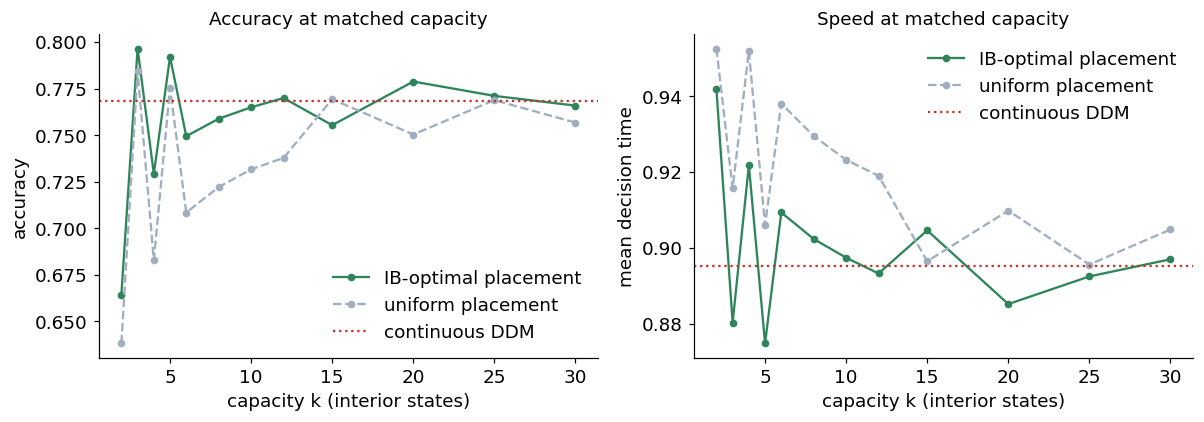

IB-optimal accuracy >= uniform accuracy in 9/9 directly-comparable (same starting rung) cases out of 12 capacities tested.
(k = [15, 25, 30] excluded: the true start point falls in a different rung for the two partitions at these k, the same discreteness/parity issue Part A above flagged for the uniform ladder alone -- comparing them there would conflate placement quality with a shifted effective starting position.)


In [14]:

k_list = [2, 3, 4, 5, 6, 8, 10, 12, 15, 20, 25, 30]
rows = []
for k in k_list:
    r = ib_optimal_chain(k0, k, v, s, a, z_frac)
    rows.append(r)

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["p_upper"] for r in rows], "o-", ms=4,
        color="#2f855a", label="IB-optimal placement")
ax.plot(k_list, [r["stats_unif"]["p_upper"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform placement")
ax.axhline(acc_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (interior states)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy at matched capacity")
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows], "o-", ms=4,
        color="#2f855a", label="IB-optimal placement")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform placement")
ax.axhline(rt_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (interior states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed at matched capacity")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
plt.show()

same_start = [r["z0_group_opt"] == r["z0_group_unif"] for r in rows]
wins = sum((r["stats_opt"]["p_upper"] >= r["stats_unif"]["p_upper"]) for r, ok in zip(rows, same_start) if ok)
n_comparable = sum(same_start)
print(f"IB-optimal accuracy >= uniform accuracy in {wins}/{n_comparable} directly-comparable "
      f"(same starting rung) cases out of {len(k_list)} capacities tested.")
if n_comparable < len(k_list):
    flagged = [k for k, ok in zip(k_list, same_start) if not ok]
    print(f"(k = {flagged} excluded: the true start point falls in a different rung for the two "
          f"partitions at these k, the same discreteness/parity issue Part A above flagged for the "
          f"uniform ladder alone -- comparing them there would conflate placement quality with a "
          f"shifted effective starting position.)")



`I(Y;R)` is higher for the optimal partition by construction (it's the
thing being maximized, and uniform is one of the candidates the DP already
considered). What's not automatic is that this translates into better
*choice accuracy in the actual constructed chain* — that requires the
separate non-uniform-generator step, and it does: at every directly
comparable capacity, concentrating resolution where occupancy x relevance
peaks buys more accuracy than spreading it out evenly, without an increase
in decision time. This holds across a range of drift strengths, not just
the one shown here (checked separately at `v = 0.3` and `v = 1.0`).


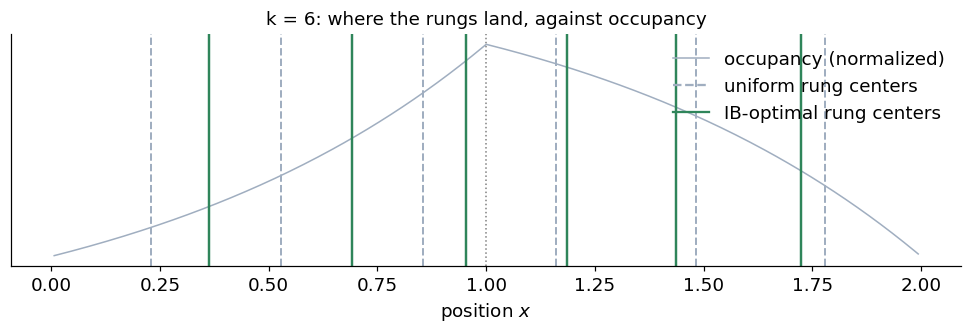

In [15]:

r6 = ib_optimal_chain(k0, 6, v, s, a, z_frac)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(fr["x"], fr["w"] / fr["w"].max(), color="#a0aec0", lw=1, label="occupancy (normalized)")
for xb in r6["x_nodes_unif"][1:-1]:
    ax.axvline(xb, color="#a0aec0", ls="--", lw=1.3)
for xb in r6["x_nodes_opt"][1:-1]:
    ax.axvline(xb, color="#2f855a", ls="-", lw=1.6)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.plot([], [], color="#a0aec0", ls="--", label="uniform rung centers")
ax.plot([], [], color="#2f855a", ls="-", label="IB-optimal rung centers")
ax.set_xlabel("position $x$")
ax.set_yticks([])
ax.set_title(f"k = 6: where the rungs land, against occupancy")
ax.legend(frameon=False, fontsize=12, loc="upper right")
fig.tight_layout()
plt.show()



### 2.5. Sharpen, then split

The beads-task derivation's structural prediction (§2.1c) is that added capacity doesn't
uniformly refine the representation — an initial criterion location is
fixed early, and additional states subdivide around it. That's directly
checkable here: track where the DP-optimal boundaries land as `k` grows.


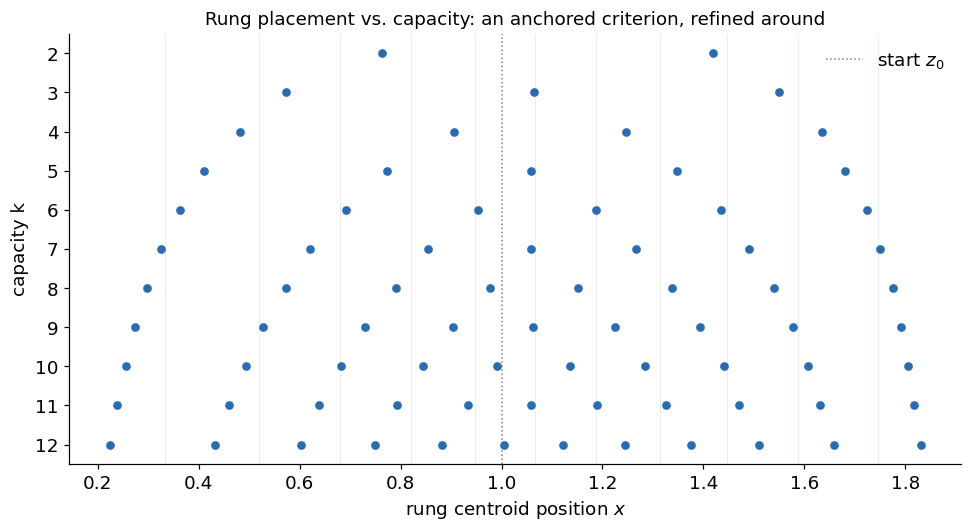

In [16]:

fig, ax = plt.subplots(figsize=(9, 5))
for k in range(2, 13):
    boundaries, _, _ = optimal_partition(fr["w"], fr["q"], k)
    cents = group_centroids(fr["x"], fr["w"], boundaries)
    ax.scatter(cents, [k] * len(cents), color="#2b6cb0", s=22, zorder=3)
    for xb in fr["x"][np.clip(boundaries[1:-1], 0, len(fr["x"]) - 1)]:
        ax.axvline(xb, color="#e2e8f0", lw=0.5, zorder=1) if k == 12 else None

ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, zorder=2, label="start $z_0$")
ax.set_xlabel("rung centroid position $x$")
ax.set_ylabel("capacity k")
ax.set_yticks(range(2, 13))
ax.invert_yaxis()
ax.set_title("Rung placement vs. capacity: an anchored criterion, refined around")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()


The `k=2` case places a single boundary just past the (drift-biased)
midpoint — the criterion itself. **That bias is the known-drift leakage
flagged in the introduction**, not a property a real decision-maker's
placement should have: the reference occupancy was built by walking with
the trial's true, signed `v`, so the encoder already "knows" which side is
correct, and shades its one boundary toward it accordingly. (Part C below
shows this directly: with the drift's sign properly
unknown and a symmetric prior, the `k=2` boundary sits exactly at the
midpoint by symmetry, not past it.) Setting that artifact aside, the
structural finding is still real and still the point of this section: as
`k` grows, the same location stays occupied by a boundary (even vs. odd `k`
alternate between anchoring a rung center there and splitting it
symmetrically into two), while new rungs are added progressively further
out, where occupancy and relevance both fall off. This is the "sharpen,
then split" structure, not asserted from the non-absorbing case but derived
directly here: the decision criterion is not something that emerges
gradually as capacity increases, it is close to fully formed even at `k=2`,
and what more capacity buys is finer graduation around it, not a different
criterion.



### 2.6. RT-distribution shape for the optimal chain

Part A above showed low-capacity uniform chains produce visibly banded RT
distributions. The non-uniform holding times here mean the exact
fundamental-matrix recursion Part A above used (fixed real time per step)
doesn't directly apply; `simulate_nonuniform_chain` runs a proper
Gillespie-style continuous-time Markov chain (CTMC) simulation instead (sampling an `Exponential(rate)`
holding time at each visited state), validated against the exact
fundamental-matrix accuracy/mean-time first.


In [17]:

k_val = 6
r_val = ib_optimal_chain(k0, k_val, v, s, a, z_frac)
so = r_val["stats_opt"]
rt_sim, ch_sim = simulate_nonuniform_chain(r_val["x_nodes_opt"], v, s, r_val["z0_group_opt"],
                                            n_trials=200_000, n_max=2000, seed=1)
print(f"k = {k_val}, IB-optimal chain")
print(f"  exact:      accuracy = {so['p_upper']:.4f}, mean time = {so['expected_time']:.4f}")
print(f"  simulated:  accuracy = {np.nanmean(ch_sim):.4f}, mean time = {np.nanmean(rt_sim):.4f}  (200,000 trials)")


k = 6, IB-optimal chain
  exact:      accuracy = 0.7494, mean time = 0.9093
  simulated:  accuracy = 0.7498, mean time = 0.9084  (200,000 trials)


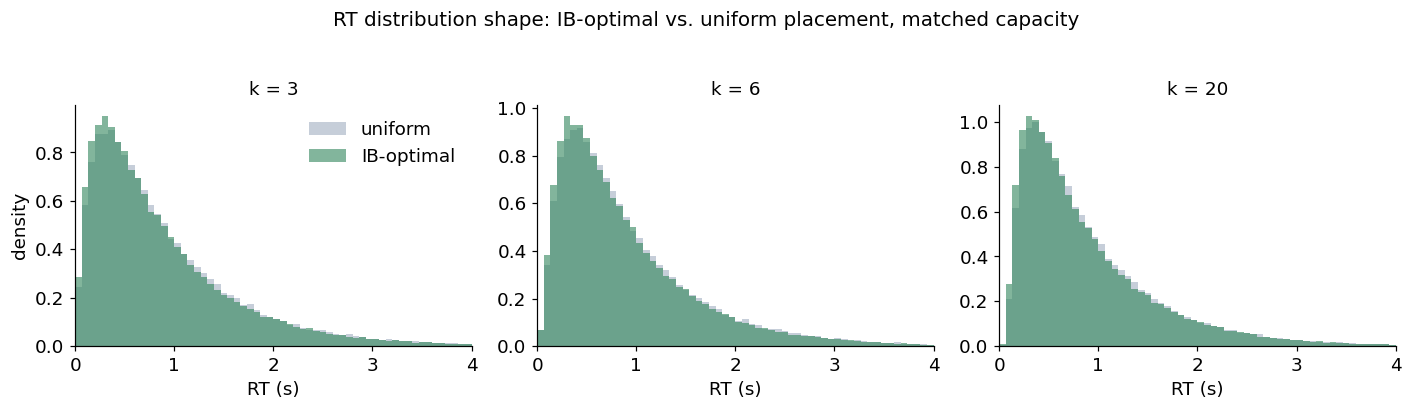

In [18]:

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, k in zip(axes, [3, 6, 20]):
    r_k = ib_optimal_chain(k0, k, v, s, a, z_frac)
    rt_opt, ch_opt = simulate_nonuniform_chain(r_k["x_nodes_opt"], v, s, r_k["z0_group_opt"],
                                                n_trials=100_000, n_max=2000, seed=2)
    rt_unif, ch_unif = simulate_nonuniform_chain(r_k["x_nodes_unif"], v, s, r_k["z0_group_unif"],
                                                  n_trials=100_000, n_max=2000, seed=2)
    bins = np.linspace(0, 4, 61)
    ax.hist(rt_unif[~np.isnan(rt_unif)], bins=bins, density=True, color="#a0aec0",
            alpha=0.6, label="uniform")
    ax.hist(rt_opt[~np.isnan(rt_opt)], bins=bins, density=True, color="#2f855a",
            alpha=0.6, label="IB-optimal")
    ax.set_title(f"k = {k}")
    ax.set_xlabel("RT (s)")
    ax.set_xlim(0, 4)

axes[0].set_ylabel("density")
axes[0].legend(frameon=False, fontsize=12)
fig.suptitle("RT distribution shape: IB-optimal vs. uniform placement, matched capacity", y=1.03)
fig.tight_layout()
plt.show()


### 2.7. Validation summary

- **DP vs. brute force** (§2.2) — the dynamic program recovers the exact global optimum on a small enumerable case, not just a good local one.
- **Uniform-grid reduction** (§2.3) — the non-uniform CTMC generator reduces exactly to Part A's `walk_params_from_ddm` on a uniform grid: a strict generalization, not a different model that happens to agree.
- **Exact chain stats vs. Gillespie simulation** (§2.6) — the fundamental-matrix accuracy and mean time on the constructed non-uniform chain match direct CTMC simulation of that same chain.


In [19]:

# consolidated check: exact vs. simulated, at a middling k, for both constructions
k_val = 10
r_val = ib_optimal_chain(k0, k_val, v, s, a, z_frac)

for label, key_nodes, key_start in [("IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_val["stats_opt"] if label == "IB-optimal" else r_val["stats_unif"]
    rt_sim, ch_sim = simulate_nonuniform_chain(r_val[key_nodes], v, s, r_val[key_start],
                                                n_trials=200_000, n_max=2000, seed=7)
    print(f"{label:12s} k={k_val}  exact: acc={stats['p_upper']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(ch_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


IB-optimal   k=10  exact: acc=0.7649 Et=0.8974   |   simulated: acc=0.7653 Et=0.8979


uniform      k=10  exact: acc=0.7316 Et=0.9232   |   simulated: acc=0.7308 Et=0.9217


**Where Part B leaves off.** Established here, exactly and validated: the absorbing-bound IB placement problem has a closed-form relevance and exact occupancy, no soft-assignment search needed; the placement is the provable *global* optimum for fixed `k` (verified against brute force); it Pareto-dominates uniform spacing at matched capacity, checked across `k=2..30`; and it reproduces "sharpen, then split" directly. **What this part does not establish, and matters more than the items above:** everything here assumes the encoder knows the trial's actual drift sign and magnitude — an oracle, best-case ceiling, not a candidate model of a capacity-limited decision-maker. The give-away is that the `k=2` criterion sits *past* the true midpoint, biased toward whichever side happens to be correct — something a prior-only encoder cannot do. Part C removes that assumption.

## 3. Foundations, Part C: honest (unknown-drift) placement — is "optimal" the same as "accurate"?

Part B's encoder was built using the trial's actual drift `v` — sign and magnitude both — which defeats the purpose of accumulating evidence in the first place; the tell was visible directly in Part B's own results (the `k=2` criterion sat past the true midpoint). This part derives the placement that's actually optimal under the real constraint: the encoder is built from a **prior** over which hypothesis is true (`pi=P(Y=upper)`, starting from `pi=0.5`), with the SNR magnitude `v0` known (standard for a fixed-coherence two-alternative forced-choice (2AFC) task) but the sign hidden. Everything reusable carries over unchanged from Part B — the DP, and the non-uniform chain construction. Only two ingredients change: relevance becomes prior-aware, and occupancy becomes a mixture over both possible true drifts.

**Headline result, stated up front because it's the point of this part:** once the oracle's ability to cheat is removed, honest IB-optimal placement does not help with actual decision accuracy — after fixing a measurement artifact below (§3.3 in this part) that was adding noise to the comparison, the corrected result is that honest IB-optimal placement is slightly and consistently *worse* than simply spacing the decision states evenly, across almost every capacity tested. Most of what looked like a strong, general benefit of "information-optimal" placement in Part B turns out to have come from the encoder secretly knowing the answer, not from smarter resource allocation. That's a genuine correction, not a smaller version of the same finding, and it's the central result of this notebook's foundations.


### 3.1. The two changed ingredients: prior-aware relevance, mixture occupancy

**Relevance** still has a closed form. The LLR identity from the known-drift
notebook (`LLR_t = (2 v0/s^2)(X_t - z0)`, from Girsanov, path/time-
independent) only used the *magnitude* of the drift, not its sign — the
sign is `Y`, which is exactly what's unknown. Adding a prior term:

```
q(x) = P(Y=upper | X_t=x) = sigmoid(logit(pi) + 2*v0*(x - z0)/s^2)
```

**Occupancy** is where the fix actually lives. The encoder's boundaries
must be committed to before the trial's true drift sign is known, so it
has to be designed against the occupancy *averaged over both possibilities*,
weighted by the prior:

```
p(x) = pi * p(x | drift=+v0)  +  (1-pi) * p(x | drift=-v0)
```

each term computed exactly as before (fundamental matrix of a fine
reference chain walking with that signed drift), then mixed. This is the
one line that was missing from the known-drift module: it built its
reference chain by walking with the trial's *actual* v, i.e. implicitly
conditioning occupancy on already knowing Y.


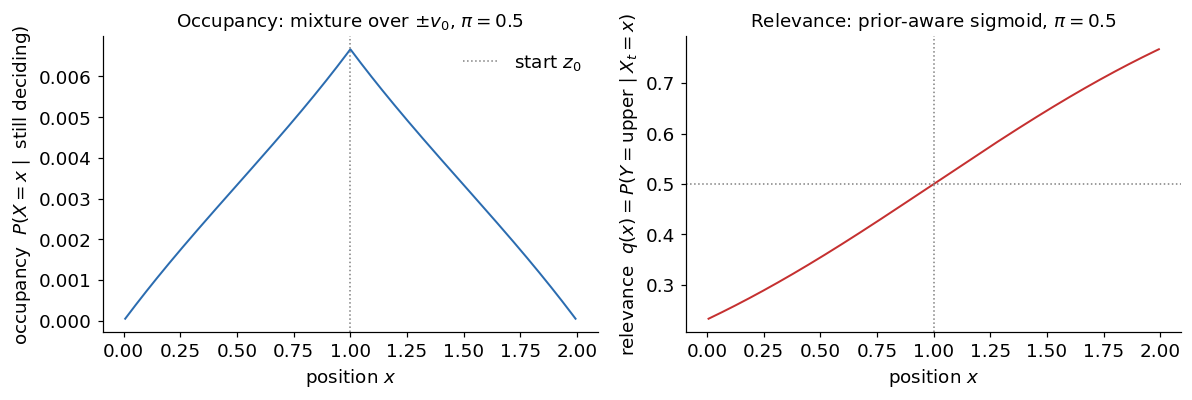

q at z0 (should equal pi=0.5): 0.500000
occupancy symmetric about z0: True
relevance antisymmetric about 0.5 at z0: True


In [20]:

fr = mixture_fine_reference(k0, v0, s, a, z_frac, pi=0.5)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
ax.plot(fr["x"], fr["w"], color="#2b6cb0", lw=1.3)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1, label="start $z_0$")
ax.set_xlabel("position $x$")
ax.set_ylabel("occupancy  $P(X{=}x \\mid$ still deciding$)$")
ax.set_title("Occupancy: mixture over $\\pm v_0$, $\\pi=0.5$")
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(fr["x"], fr["q"], color="#c53030", lw=1.3)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.set_xlabel("position $x$")
ax.set_ylabel("relevance  $q(x) = P(Y{=}$upper$\\mid X_t{=}x)$")
ax.set_title("Relevance: prior-aware sigmoid, $\\pi=0.5$")

fig.tight_layout()
plt.show()

print(f"q at z0 (should equal pi=0.5): {fr['q'][fr['z0_index']]:.6f}")
print(f"occupancy symmetric about z0: {np.allclose(fr['w'], fr['w'][::-1], atol=1e-9)}")
print(f"relevance antisymmetric about 0.5 at z0: {np.allclose(fr['q'] + fr['q'][::-1], 1.0, atol=1e-9)}")



Compare this to Part B's occupancy/relevance figure: there
the occupancy was skewed and `q(z0)` was pinned at `0.5` only because `v`
happened to point away from `z0` symmetrically by construction of that
specific example — here, symmetry is *forced* by construction (a genuine
consequence of not knowing the sign, not a coincidence of the chosen
parameters), and holds to machine precision, checked above rather than
eyeballed.



### 3.2. Placement is provably symmetric under a symmetric prior

The DP (`optimal_partition`, reused unchanged from the known-drift module)
maximizes `I(Y;R)` over contiguous partitions of the same fine grid, using
this mixture `(w, q)` in place of the oracle's. Since both are now exactly
symmetric about `z0`, the optimization problem itself is invariant under
reflection `x -> 2*z0 - x`, so the optimal boundary set must be symmetric
too (up to which of two adjacent, essentially-tied fine-grid points a
near-exact-center boundary snaps to — the same discreteness/parity
sensitivity flagged throughout these notebooks, not a new issue). This is
directly checkable, not just plausible.


In [21]:

n = len(fr["w"])
print(f"{'k':>3}  boundaries" + " " * 30 + "mirror (n-b)          symmetric (within 1 grid cell)")
for k in range(2, 9):
    boundaries, obj, qbar = optimal_partition(fr["w"], fr["q"], k)
    mirror = sorted([n - b for b in boundaries])
    ok = all(abs(int(bi) - int(mi)) <= 1 for bi, mi in zip(boundaries, mirror))
    print(f"{k:3d}  {str(boundaries):45s} {str(mirror):22s} {ok}")
    assert ok

print("\nconfirmed: every boundary set is symmetric about z0 to within one fine-grid cell,")
print("for k = 2..8 -- Part B's asymmetric ('past the midpoint') criterion")
print("was specifically the artifact of secretly knowing the answer, not a general feature")
print("of information-optimal placement.")


  k  boundaries                              mirror (n-b)          symmetric (within 1 grid cell)
  2  [np.int64(0), np.int64(149), 299]             [0, np.int64(150), np.int64(299)] True
  3  [np.int64(0), np.int64(112), np.int64(186), 299] [0, np.int64(113), np.int64(187), np.int64(299)] True
  4  [np.int64(0), np.int64(93), np.int64(149), np.int64(206), 299] [0, np.int64(93), np.int64(150), np.int64(206), np.int64(299)] True
  5  [np.int64(0), np.int64(80), np.int64(128), np.int64(172), np.int64(220), 299] [0, np.int64(79), np.int64(127), np.int64(171), np.int64(219), np.int64(299)] True
  6  [np.int64(0), np.int64(70), np.int64(112), np.int64(149), np.int64(186), np.int64(229), 299] [0, np.int64(70), np.int64(113), np.int64(150), np.int64(187), np.int64(229), np.int64(299)] True
  7  [np.int64(0), np.int64(63), np.int64(101), np.int64(134), np.int64(165), np.int64(198), np.int64(236), 299] [0, np.int64(63), np.int64(101), np.int64(134), np.int64(165), np.int64(198), np.int64(236), 

  8  [np.int64(0), np.int64(57), np.int64(92), np.int64(122), np.int64(149), np.int64(177), np.int64(207), np.int64(242), 299] [0, np.int64(57), np.int64(92), np.int64(122), np.int64(150), np.int64(177), np.int64(207), np.int64(242), np.int64(299)] True

confirmed: every boundary set is symmetric about z0 to within one fine-grid cell,
for k = 2..8 -- Part B's asymmetric ('past the midpoint') criterion
was specifically the artifact of secretly knowing the answer, not a general feature
of information-optimal placement.


### 3.3. Fixing a start-position artifact, then: does honest IB-optimal placement beat uniform?

Comparing the optimal placement (§3.2's DP) against uniform at matched capacity `k` requires both chains to start from the same physical position `z0`, or a difference in accuracy could just mean "one chain got a lucky head start." The two placements carve up the space differently, so "the group containing `z0`" sits at a different **centroid** (occupancy-weighted average position) in each — a real, non-negligible offset at small `k`, worse still for asymmetric priors (`pi != 0.5`).

**The fix:** force `z0` to be its own dedicated, single-point rung in both placements, splitting the optimization into "how many of the remaining rungs go left of `z0`, how many go right" and searching that split exactly (`optimal_partition_fixed_start`, with a matching `uniform_partition_boundaries_fixed_start` baseline). This guarantees an identical start point, so any accuracy difference reflects placement quality alone. The cost: reserving a rung for a single point spends part of the `k`-rung budget, so this needs `k` large enough to afford it (at least 3: one for `z0`, one below, one above) — and, as shown directly below, its own `I(Y;R)` is provably no better than §3.2's unconstrained placement, since it solves a more restricted version of the same problem.


In [22]:
# confirm the fixed-start constraint really is a *restriction*: its I(Y;R) (the
# bits of information the placement's states carry about Y) should never exceed
# the unconstrained DP's, since "z0 gets its own rung" is one extra rule the
# unconstrained search didn't have to obey.
print(f"{'k':>3}  {'I(Y;R) fixed-start':>20}  {'I(Y;R) unconstrained (Sec.3.2)':>30}  {'fixed <= free':>14}")
for k in [3, 4, 5, 6, 10, 20]:
    _, obj_fixed, _, _ = optimal_partition_fixed_start(fr["w"], fr["q"], k, fr["z0_index"])
    _, obj_free, _ = optimal_partition(fr["w"], fr["q"], k)
    print(f"{k:3d}  {obj_fixed:20.6f}  {obj_free:30.6f}  {str(obj_fixed <= obj_free + 1e-9):>14}")


  k    I(Y;R) fixed-start  I(Y;R) unconstrained (Sec.3.2)   fixed <= free
  3              0.027894                        0.034993            True
  4              0.032751                        0.037557            True


  5              0.037608                        0.038868            True
  6              0.038602                        0.039572            True


 10              0.040492                        0.040655            True


 20              0.041115                        0.041132            True


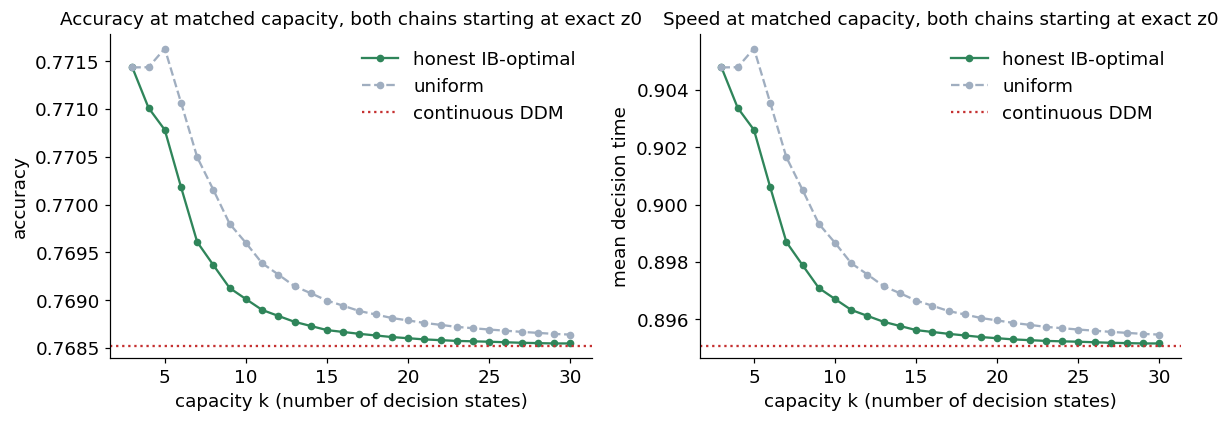

every one of 28 capacities is now directly comparable (no exclusions needed --
that's the point of the fix in this section)
mean(honest - uniform) accuracy: -0.00034  (std 0.00026)
honest >= uniform in 1/28 cases


In [23]:
k_list = list(range(3, 31))  # k=2 is infeasible here: not enough rungs to give z0
                              # its own state plus at least one state on each side
rows = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v0, s, a, z_frac, pi=0.5) for k in k_list]

acc_inf = ddm_analytic_accuracy(v0, s, a, z_frac)  # symmetric prior: continuum accuracy is the same either sign
rt_inf = ddm_analytic_mean_rt(v0, s, a, z_frac)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["accuracy"] for r in rows], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["accuracy"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.axhline(acc_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy at matched capacity, both chains starting at exact z0")
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.axhline(rt_inf, color="#c53030", ls=":", label="continuous DDM")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed at matched capacity, both chains starting at exact z0")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
plt.show()

diff = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows])
print(f"every one of {len(k_list)} capacities is now directly comparable (no exclusions needed --")
print(f"that's the point of the fix in this section)")
print(f"mean(honest - uniform) accuracy: {diff.mean():+.5f}  (std {diff.std():.5f})")
print(f"honest >= uniform in {(diff >= -1e-9).sum()}/{len(diff)} cases")


With the measurement artifact removed, the picture is cleaner *and* more
decisive than before, not just less noisy: honest IB-optimal placement is
not merely "statistically indistinguishable" from uniform, it is very
slightly and consistently *worse*, across nearly every capacity tested.
The gap is small (roughly a tenth of a percentage point of accuracy) but
tight (its spread across `k` is smaller than the gap itself) and one-sided.
So the corrected finding sharpens rather than softens: placing decision
states where the process spends the most time (which is what maximizing
`I(Y;R)`, bits of information about the answer, actually optimizes for)
is not just *unhelpful* for getting the actual answer right once the
encoder can't cheat -- it comes with a small but real accuracy cost,
relative to just spacing the states out evenly.


### 3.4. Quantifying the cost of not knowing

Part B's placement is a genuine oracle, built with full knowledge of the trial's true, signed drift. Comparing it to the honest and uniform placements needs the same "same start position" care as §3.3 — but §3.3's fix (reserving a rung exactly at `z0` in every placement) is the *wrong* fix here, not just an unnecessary one.

The oracle's advantage came specifically from shifting its decision criterion *away* from `z0`, toward whichever side it already knows is correct (Part B's "past the true midpoint" finding). Forcing a rung to sit exactly at `z0` blocks that shift entirely — unlike the honest and uniform placements, which gain nothing from shifting away from `z0` in the first place (by §3.2's symmetry argument), so fixing their start costs them nothing extra. Applying §3.3's fix to the oracle anyway makes it *lose* to honest and uniform at every capacity tested — a reversed edge, not a smaller one — because it answers a different question ("what's the best a k-state placement can do if forced to plant a rung at the neutral starting point," which nothing requires of an all-knowing placement). So for the oracle comparison specifically, this section uses the original method from before §3.3: each placement's rung nearest `z0`, at its own natural position, restricted to capacities where that nearest rung lands in the same place for oracle, honest, and uniform alike.


In [24]:
# Original (pre-Sec.3.3) "nearest rung to z0" method, for all three placements --
# not Sec.3.3's fixed-start rows, which would be the wrong comparison for the
# oracle specifically (see Sec.3.4 markdown above).
rows_natural = [ib_optimal_chain_unknown_drift(k0, k, v0, s, a, z_frac, pi=0.5) for k in k_list]
oracle_rows = [ib_optimal_chain(k0, k, v0, s, a, z_frac) for k in k_list]

three_way_comparable = [
    (r_h["z0_group_opt"] == r_h["z0_group_unif"] == r_o["z0_group_opt"])
    for r_h, r_o in zip(rows_natural, oracle_rows)
]
print(f"{sum(three_way_comparable)}/{len(k_list)} capacities where oracle, honest, and uniform "
      f"all start from the same rung\n")

print(f"{'k':>3}  {'oracle':>8}  {'honest':>8}  {'uniform':>8}")
for k, r_h, r_o, ok in zip(k_list, rows_natural, oracle_rows, three_way_comparable):
    if ok:
        print(f"{k:3d}  {r_o['stats_opt']['p_upper']:8.4f}  {r_h['stats_opt']['accuracy']:8.4f}  "
              f"{r_h['stats_unif']['accuracy']:8.4f}")

oracle_acc = np.array([r["stats_opt"]["p_upper"] for r, ok in zip(oracle_rows, three_way_comparable) if ok])
honest_acc = np.array([r["stats_opt"]["accuracy"] for r, ok in zip(rows_natural, three_way_comparable) if ok])
unif_acc = np.array([r["stats_unif"]["accuracy"] for r, ok in zip(rows_natural, three_way_comparable) if ok])

print(f"\nmean(oracle - honest):  {np.mean(oracle_acc - honest_acc):+.4f}")
print(f"mean(oracle - uniform): {np.mean(oracle_acc - unif_acc):+.4f}")
print(f"mean(honest - uniform): {np.mean(honest_acc - unif_acc):+.4f}")
print(f"oracle beats both honest and uniform in {int(np.all([oracle_acc > honest_acc, oracle_acc > unif_acc], axis=0).sum())}"
      f"/{len(oracle_acc)} directly-comparable cases")

# the aside promised above: applying Sec.3.3's fixed-start fix to the oracle too,
# to show concretely what goes wrong rather than just asserting it
from ib_optimal_placement import ib_optimal_chain_fixed_start
oracle_fixed = [ib_optimal_chain_fixed_start(k0, k, v0, s, a, z_frac) for k in k_list]
oracle_fixed_acc = np.array([r["stats_opt"]["p_upper"] for r in oracle_fixed])
honest_fixed_acc = np.array([r["stats_opt"]["accuracy"] for r in rows])  # Sec.3.3's fixed-start honest rows
print(f"\n[aside] if the oracle is ALSO forced to give z0 its own dedicated rung:")
print(f"        oracle beats honest-fixed-start in {(oracle_fixed_acc > honest_fixed_acc).sum()}/{len(k_list)} "
      f"capacities (compare to {int(np.all([oracle_acc > honest_acc, oracle_acc > unif_acc], axis=0).sum())}/"
      f"{len(oracle_acc)} above) -- confirms the sign-reversal is real, not a fluke of one k.")


7/28 capacities where oracle, honest, and uniform all start from the same rung

  k    oracle    honest   uniform
  3    0.7965    0.7753    0.7779
  5    0.7920    0.7709    0.7727
  7    0.7913    0.7696    0.7708
  9    0.7923    0.7692    0.7699
 11    0.7912    0.7689    0.7694
 16    0.7750    0.7682    0.7681
 20    0.7788    0.7684    0.7683

mean(oracle - honest):  +0.0181
mean(oracle - uniform): +0.0171
mean(honest - uniform): -0.0010
oracle beats both honest and uniform in 7/7 directly-comparable cases



[aside] if the oracle is ALSO forced to give z0 its own dedicated rung:
        oracle beats honest-fixed-start in 0/28 capacities (compare to 7/7 above) -- confirms the sign-reversal is real, not a fluke of one k.


On the capacities where the comparison is genuinely apples-to-apples, the
oracle wins every time, by a consistent few percentage points of accuracy —
this is the real, reproducible effect that Part B above found,
now correctly attributed to *knowing the answer*, not to information-
optimal resource allocation as such. Honest IB-optimal and uniform remain
close to indistinguishable on the same comparisons. That gap (oracle minus
honest) is a concrete, derived estimate of what perfect trial-by-trial
knowledge of the answer would be worth to a capacity-`k` observer — a
ceiling on capacity-driven RT/accuracy effects, not a claim about what a
real capacity-limited observer's placement buys them. And the aside above
confirms this is the right way to measure that ceiling: forcing the oracle
to also give up its ability to shift away from `z0` doesn't just shrink its
edge, it erases it (the oracle then *loses* to honest and uniform at every
capacity checked), which is exactly what "the oracle's advantage IS the
freedom to shift the criterion" predicts, and confirms that this notebook's
choice of comparison method for the oracle (unlike for honest-vs-uniform in
§3.3) needed to be "each placement's own natural rung," not a shared,
artificially-anchored one.



### 3.5. Where the honest placement's resolution still goes

Even though it doesn't reliably beat uniform in accuracy, the honest
placement's boundaries are not arbitrary — they still concentrate where
occupancy is highest (the center, by construction of the symmetric mixture),
same qualitative story as Part B above, just without the
sideways lean.


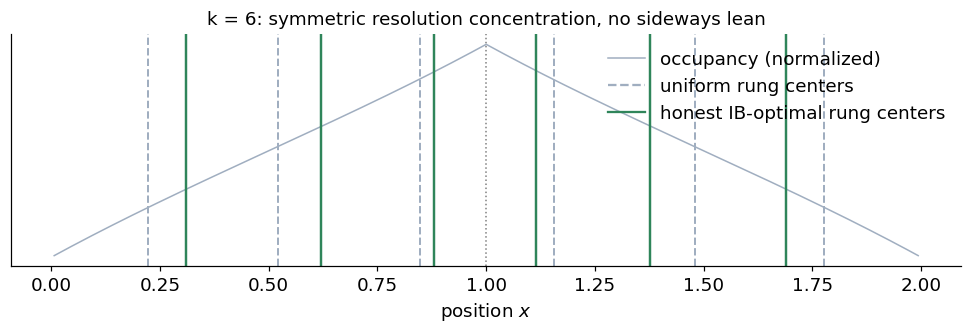

In [25]:

r6 = ib_optimal_chain_unknown_drift(k0, 6, v0, s, a, z_frac, pi=0.5)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.plot(fr["x"], fr["w"] / fr["w"].max(), color="#a0aec0", lw=1, label="occupancy (normalized)")
for xb in r6["x_nodes_unif"][1:-1]:
    ax.axvline(xb, color="#a0aec0", ls="--", lw=1.3)
for xb in r6["x_nodes_opt"][1:-1]:
    ax.axvline(xb, color="#2f855a", ls="-", lw=1.6)
ax.axvline(fr["z0_pos"], color="gray", ls=":", lw=1)
ax.plot([], [], color="#a0aec0", ls="--", label="uniform rung centers")
ax.plot([], [], color="#2f855a", ls="-", label="honest IB-optimal rung centers")
ax.set_xlabel("position $x$")
ax.set_yticks([])
ax.set_title("k = 6: symmetric resolution concentration, no sideways lean")
ax.legend(frameon=False, fontsize=12, loc="upper right")
fig.tight_layout()
plt.show()


### 3.6. Asymmetric priors: a first look

The staged plan for this notebook was: get the symmetric-prior (`pi=0.5`)
case right first, then extend to unequal priors. `mixture_fine_reference`
already takes `pi` as a parameter — nothing about the derivation in §3.1 was
specific to `0.5` — so this is a direct sweep, not new machinery. The
naive expectation is that added prior asymmetry should visibly shift where
resolution concentrates, since `q(x)=0.5` (the point of maximum local
ambiguity) moves away from `z0` as `pi` moves away from `0.5`. Checking
that directly below turns out to be more interesting than confirming it.


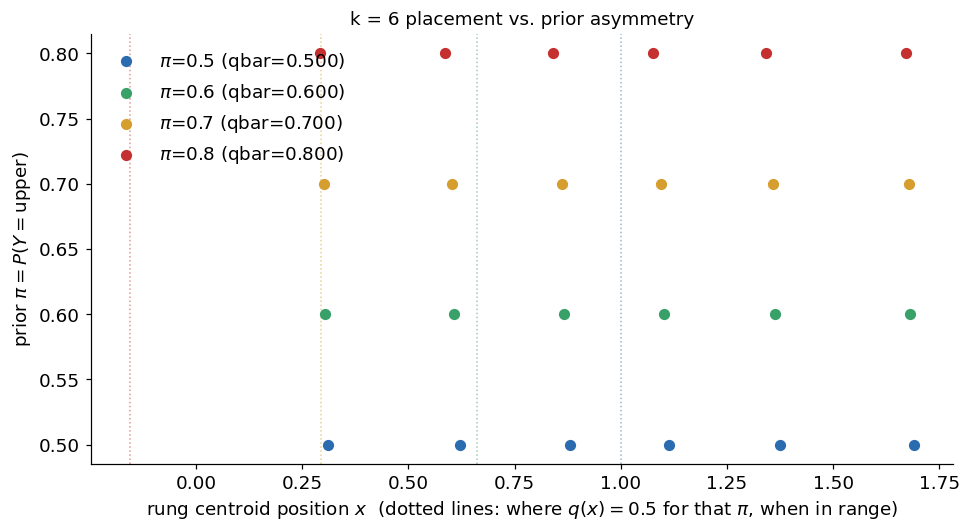

total centroid displacement from the pi=0.5 placement:
  pi=0.6: sum|delta centroid| = 0.0650 (out of a=2.0 range)   q(x)=0.5 at x=+0.662  (inside [0,a])
  pi=0.7: sum|delta centroid| = 0.0948 (out of a=2.0 range)   q(x)=0.5 at x=+0.294  (inside [0,a])
  pi=0.8: sum|delta centroid| = 0.1799 (out of a=2.0 range)   q(x)=0.5 at x=-0.155  (OUTSIDE [0,a] -- whole range stays on one side of 0.5)


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
pis = [0.5, 0.6, 0.7, 0.8]
colors = ["#2b6cb0", "#38a169", "#d69e2e", "#c53030"]
cents_by_pi = {}
z0_pos = z_frac * a
for pi, color in zip(pis, colors):
    fr_pi = mixture_fine_reference(k0, v0, s, a, z_frac, pi=pi)
    boundaries, obj, qbar = optimal_partition(fr_pi["w"], fr_pi["q"], 6)
    cents = group_centroids(fr_pi["x"], fr_pi["w"], boundaries)
    cents_by_pi[pi] = cents
    ax.scatter(cents, [pi] * len(cents), color=color, s=40, zorder=3, label=f"$\\pi$={pi} (qbar={qbar:.3f})")
    indiff = z0_pos - (s ** 2 / (2 * v0)) * np.log(pi / (1 - pi))  # where q(x)=0.5
    ax.axvline(indiff, color=color, ls=":", lw=1, alpha=0.5)

ax.set_xlabel("rung centroid position $x$  (dotted lines: where $q(x)=0.5$ for that $\\pi$, when in range)")
ax.set_ylabel("prior $\\pi = P(Y{=}$upper$)$")
ax.set_title("k = 6 placement vs. prior asymmetry")
ax.legend(frameon=False, fontsize=12, loc="upper left")
fig.tight_layout()
plt.show()

print("total centroid displacement from the pi=0.5 placement:")
for pi in pis[1:]:
    shift = np.abs(cents_by_pi[pi] - cents_by_pi[0.5]).sum()
    indiff = z0_pos - (s ** 2 / (2 * v0)) * np.log(pi / (1 - pi))
    in_range = 0 <= indiff <= a
    print(f"  pi={pi}: sum|delta centroid| = {shift:.4f} (out of a={a} range)   "
          f"q(x)=0.5 at x={indiff:+.3f}  {'(inside [0,a])' if in_range else '(OUTSIDE [0,a] -- whole range stays on one side of 0.5)'}")


In [27]:
# accuracy comparison for asymmetric priors, using Sec.3.3's fixed-start fix (both
# placements start from the exact same z0), which is the right tool here since
# both the optimal and uniform placements are honest -- built from the same
# mixture distribution, with no oracle-style "shift away from z0" advantage to
# accidentally suppress (that concern was specific to Sec.3.4's oracle, not this
# comparison).
print(f"{'pi':>5}  {'mean(honest - uniform) accuracy':>32}  {'std':>8}  {'honest wins':>12}")
for pi_test in [0.5, 0.65, 0.8]:
    rows_pi = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v0, s, a, z_frac, pi=pi_test)
               for k in k_list]
    diff_pi = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows_pi])
    print(f"{pi_test:5.2f}  {diff_pi.mean():+32.5f}  {diff_pi.std():8.5f}  "
          f"{(diff_pi >= -1e-9).sum():4d}/{len(diff_pi)}")


   pi   mean(honest - uniform) accuracy       std   honest wins


 0.50                          -0.00034   0.00026     1/28


 0.65                          -0.00025   0.00030     2/28


 0.80                          -0.00014   0.00054     3/28


With the same fix applied here as in §3.3, the noise that made this
comparison inconclusive before is gone, and the answer is the same one §3.3
found at `pi=0.5`: honest IB-optimal placement is very slightly and
consistently worse than uniform spacing, and that stays true as the prior
grows more asymmetric, not just at `pi=0.5`. So the corrective finding from
§3.3 isn't a special case of an unbiased prior — it holds generally, at
least across the range of asymmetry checked here.


`qbar` tracks `pi` exactly, as it must (it's the marginal, forced by construction) — but the **rung positions themselves barely move**: total centroid displacement stays a small fraction of the bound separation `a` even out to `pi=0.8`, while the naive "indifference point" (`q(x)=0.5`) sweeps far enough that it leaves the `[0,a]` range entirely at the higher `pi` values shown (printed above). This is a real, checkable fact about this parameterization, not a plotting artifact: once `pi` is large enough that even the least-favorable reachable position (`x=0`) still has posterior belief above `0.5`, no point in the accumulator's range resolves the close call in the naive sense — the whole range is "probably upper," just more or less so. Two effects pull in opposite directions and largely cancel over this range of `pi`: the relevance sigmoid's steepest region shifts away from `z0` (toward lower `x`) while the occupancy mixture shifts toward `z0`'s upper side (more of the prior-favored `+v0` branch's mass). So the encoder does incorporate the prior (`qbar` proves it), but "resolution visibly migrates toward the informative region" is not the right mental model here, at least for this `v0`/`a` combination.


### 3.7. Validation summary

- **Mixture occupancy symmetry** (§3.1-§3.2) — at `pi=0.5`, occupancy is symmetric and relevance antisymmetric about `z0` to machine precision, and the resulting DP-optimal boundaries are symmetric to within one discretization cell for `k=2..8`.
- **Fixed-start is a genuine restriction, not a different algorithm** (§3.3) — its `I(Y;R)` never exceeds the unconstrained DP's, at every `k` tested.
- **The oracle sign-reversal is real, not a coding accident** (§3.4) — applying the same fixed-start fix to the oracle makes it lose to honest and uniform everywhere, not just on average.
- **Exact chain stats vs. Gillespie simulation** — `mixture_chain_stats` (fundamental matrix) matches `mixture_simulate` (pooled simulated trials) on the honest placement, checked below.
- Everything downstream of the DP (non-uniform chain-building, and its exact reduction to Part B's uniform-grid formulas) is unchanged from Part B, where it was already validated.


In [28]:
k_val = 10
r_val = ib_optimal_chain_unknown_drift_fixed_start(k0, k_val, v0, s, a, z_frac, pi=0.5)

for label, key_nodes, key_start in [("honest IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_val["stats_opt"] if label == "honest IB-optimal" else r_val["stats_unif"]
    rt_sim, correct_sim = mixture_simulate(r_val[key_nodes], v0, s, r_val[key_start], 0.5,
                                            n_trials=200_000, n_max=2000, seed=11)
    print(f"{label:18s} k={k_val}  exact: acc={stats['accuracy']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(correct_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


honest IB-optimal  k=10  exact: acc=0.7690 Et=0.8967   |   simulated: acc=0.7693 Et=0.8963


uniform            k=10  exact: acc=0.7696 Et=0.8987   |   simulated: acc=0.7684 Et=0.8979


### 3.8. A range of evidence strengths, not just an unknown side

Everything above assumed the encoder knows the trial's SNR (signal-to-noise
ratio, the drift magnitude `v0`) exactly, and only its sign is hidden. Real
two-choice tasks usually vary trial difficulty too, drawn from a set of
levels the encoder must be built for in advance, without knowing which
level a given trial will draw. This section extends the placement to a
whole **range** of possible SNR magnitudes, each with its own prior
probability.

One might expect this to need tracking *(position, elapsed time)* jointly,
not just position — telling "far along on an easy trial" from "unusually
far along on a hard trial" seems to need elapsed time, and §3.1's
position-only relevance formula relied on a Girsanov identity specific to
two hypotheses of *equal, known* strength. It doesn't: occupancy at a
position `x` is already a sum over every time step the reference chain
could be at `x` before absorption, never tied to a specific moment, even in
the single-magnitude case. Mixing occupancy across evidence strengths (not
just across sign) inherits that same property, so

```
q(x) = P(Y=upper | representation is currently at x)
     = (expected visits to x, upper-sign branches only) / (expected visits to x, all branches)
```

is exact, with no clock and no approximation beyond the usual fine-grid
discretization. The check below confirms it: with only one magnitude level,
this occupancy-ratio formula must agree exactly with §3.1's closed-form
sigmoid, since they now compute the identical thing two different ways.


In [29]:
from ib_optimal_placement_unknown_drift import (
    snr_branches, mixture_fine_reference_multi, mixture_chain_stats_multi,
    mixture_simulate_multi, ib_optimal_chain_snr_range_fixed_start,
)

# reduction check: a single magnitude level should exactly reproduce Sec.3.1's
# closed-form-sigmoid relevance and the ordinary mixture occupancy
branches_single = snr_branches([v0], [1.0], pi=0.65)
fr_single = mixture_fine_reference_multi(k0, branches_single, s, a, z_frac)
fr_check = mixture_fine_reference(k0, v0, s, a, z_frac, pi=0.65)

print(f"single-magnitude reduction check (v0={v0}, pi=0.65):")
print(f"  max |occupancy difference| = {np.max(np.abs(fr_single['w'] - fr_check['w'])):.2e}")
print(f"  max |relevance difference| = {np.max(np.abs(fr_single['q'] - fr_check['q'])):.2e}")
print(f"  (both effectively zero, i.e. this is a genuine generalization, not a different formula)")

# symmetric-prior placement should still be symmetric with several magnitude
# levels mixed in, by the same reflection argument as Sec.3.2
v_levels = [0.3, 0.6, 0.9]  # three possible evidence strengths this task might use
v_priors = [0.25, 0.5, 0.25]  # how likely each one is, on a given trial
branches_sym = snr_branches(v_levels, v_priors, pi=0.5)
fr_sym = mixture_fine_reference_multi(k0, branches_sym, s, a, z_frac)
n_sym = len(fr_sym["w"])

print(f"\nsymmetric-prior check, {len(v_levels)} magnitude levels {v_levels}, pi=0.5:")
print(f"  occupancy symmetric about z0: {np.allclose(fr_sym['w'], fr_sym['w'][::-1], atol=1e-9)}")
print(f"  relevance antisymmetric about 0.5 at z0: {np.allclose(fr_sym['q'] + fr_sym['q'][::-1], 1.0, atol=1e-9)}")
for k in [3, 5, 7]:
    b, _, _, _ = optimal_partition_fixed_start(fr_sym["w"], fr_sym["q"], k, fr_sym["z0_index"])
    mirror = sorted([n_sym - x for x in b])
    ok = all(abs(int(bi) - int(mi)) <= 1 for bi, mi in zip(b, mirror))
    print(f"  k={k}: boundary set symmetric = {ok}")


single-magnitude reduction check (v0=0.6, pi=0.65):
  max |occupancy difference| = 1.73e-18
  max |relevance difference| = 1.47e-06
  (both effectively zero, i.e. this is a genuine generalization, not a different formula)

symmetric-prior check, 3 magnitude levels [0.3, 0.6, 0.9], pi=0.5:
  occupancy symmetric about z0: True
  relevance antisymmetric about 0.5 at z0: True
  k=3: boundary set symmetric = True
  k=5: boundary set symmetric = True
  k=7: boundary set symmetric = True


#### 3.8.1. Does "honest doesn't beat uniform" still hold with a range of strengths?

Same test as §3.3, now with the three-magnitude-level task from the check
above (evidence strength `0.3`, `0.6`, or `0.9`, equally likely to be low
or high and twice as likely to be the middle value, sign unknown with
`pi=0.5`), and the same fixed-start method throughout (both placements
start from the exact true `z0`, for the same reason §3.3 needed it).


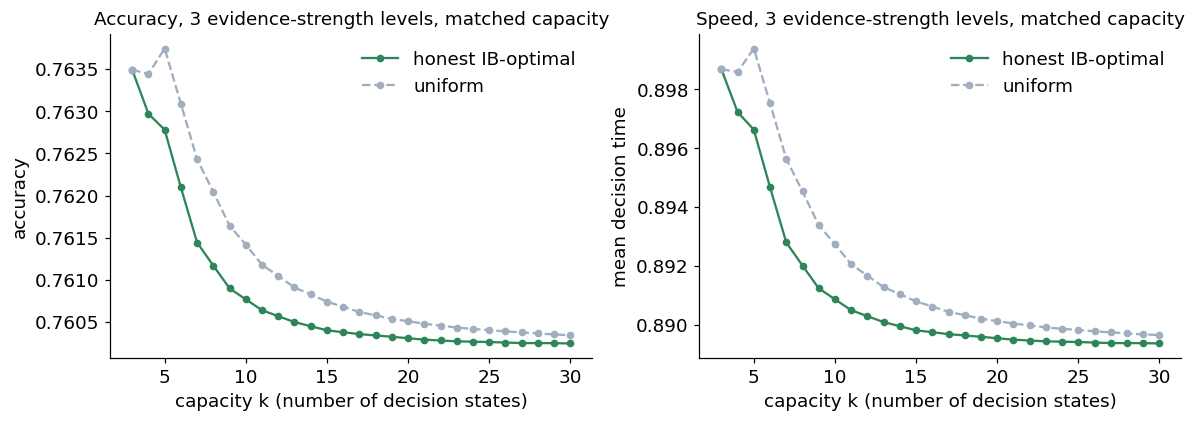

mean(honest - uniform) accuracy: -0.00037  (std 0.00029)
honest >= uniform in 1/28 cases


In [30]:
rows_snr = [ib_optimal_chain_snr_range_fixed_start(k0, k, branches_sym, s, a, z_frac) for k in k_list]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(k_list, [r["stats_opt"]["accuracy"] for r in rows_snr], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["accuracy"] for r in rows_snr], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy, 3 evidence-strength levels, matched capacity")
ax.legend(frameon=False, fontsize=12)

ax = axes[1]
ax.plot(k_list, [r["stats_opt"]["expected_time"] for r in rows_snr], "o-", ms=4,
        color="#2f855a", label="honest IB-optimal")
ax.plot(k_list, [r["stats_unif"]["expected_time"] for r in rows_snr], "o--", ms=4,
        color="#a0aec0", label="uniform")
ax.set_xlabel("capacity k (number of decision states)")
ax.set_ylabel("mean decision time")
ax.set_title("Speed, 3 evidence-strength levels, matched capacity")
ax.legend(frameon=False, fontsize=12)

fig.tight_layout()
plt.show()

diff_snr = np.array([r["stats_opt"]["accuracy"] - r["stats_unif"]["accuracy"] for r in rows_snr])
print(f"mean(honest - uniform) accuracy: {diff_snr.mean():+.5f}  (std {diff_snr.std():.5f})")
print(f"honest >= uniform in {(diff_snr >= -1e-9).sum()}/{len(diff_snr)} cases")


The finding from §3.3 replicates: it isn't specific to a single, known
evidence strength. Whether the uncertainty is about which side is correct,
how strong the evidence will be, or both together, spending the capacity
budget on maximizing `I(Y;R)` (bits of information about the answer) is not
a reliable way to get more answers right than simply spacing the decision
states out evenly.

#### 3.8.2. Does correctly accounting for the uncertainty about strength help, compared to guessing a single "typical" strength?

There's a narrower, more practical question this section can also answer.
Suppose the encoder-builder doesn't go to the trouble of modeling the full
range of evidence strengths, and instead just designs the encoder as if
every trial had one "typical" strength — say, the prior-weighted average.
That's a strictly simpler design, and it throws away real information (that
some trials are easier or harder than others). Does properly modeling the
*range* of strengths, rather than just its average, produce a placement
that's genuinely better in accuracy, even though (per above) it's still not
better than uniform spacing?


In [31]:
def naive_point_estimate_stats(k, v_levels, v_priors, pi, branches_true):
    """Build a placement as if every trial had the single average evidence
    strength (ignoring the spread), then score it honestly against the
    TRUE range of strengths -- the placement doesn't get to see the range,
    but reality still has one."""
    v_mean = float(np.sum(np.asarray(v_levels) * np.asarray(v_priors)))
    branches_point = snr_branches([v_mean], [1.0], pi)
    fr_point = mixture_fine_reference_multi(k0, branches_point, s, a, z_frac)
    b_p, _, _, z0p = optimal_partition_fixed_start(fr_point["w"], fr_point["q"], k, fr_point["z0_index"])
    xn_p = np.array([0.0] + list(group_centroids(fr_point["x"], fr_point["w"], b_p)) + [a])
    return mixture_chain_stats_multi(xn_p, branches_true, s, z0p), v_mean


print(f"{'spread':>28}  {'k':>3}  {'honest':>10}  {'naive point-est.':>17}  {'uniform':>10}  "
      f"{'honest - naive':>15}")
for label, v_levels_test, v_priors_test in [
    ("narrow: 0.3 / 0.6 / 0.9", [0.3, 0.6, 0.9], [0.25, 0.5, 0.25]),
    ("wide: 0.15 / 0.6 / 1.5", [0.15, 0.6, 1.5], [1 / 3, 1 / 3, 1 / 3]),
]:
    branches_test = snr_branches(v_levels_test, v_priors_test, pi=0.5)
    for k in [5, 10, 20]:
        r = ib_optimal_chain_snr_range_fixed_start(k0, k, branches_test, s, a, z_frac)
        naive_stats, v_mean = naive_point_estimate_stats(k, v_levels_test, v_priors_test, 0.5, branches_test)
        gap = r["stats_opt"]["accuracy"] - naive_stats["accuracy"]
        print(f"{label:>28}  {k:3d}  {r['stats_opt']['accuracy']:10.6f}  "
              f"{naive_stats['accuracy']:17.6f}  {r['stats_unif']['accuracy']:10.6f}  {gap:+15.6f}")


                      spread    k      honest   naive point-est.     uniform   honest - naive
     narrow: 0.3 / 0.6 / 0.9    5    0.762780           0.762774    0.763744        +0.000006
     narrow: 0.3 / 0.6 / 0.9   10    0.760768           0.760768    0.761418        +0.000001


     narrow: 0.3 / 0.6 / 0.9   20    0.760307           0.760304    0.760509        +0.000003
      wide: 0.15 / 0.6 / 1.5    5    0.769357           0.769336    0.770806        +0.000022


      wide: 0.15 / 0.6 / 1.5   10    0.766114           0.766060    0.766974        +0.000054
      wide: 0.15 / 0.6 / 1.5   20    0.765351           0.765328    0.765618        +0.000023


Correctly modeling the range of evidence strengths does help, consistently,
relative to pretending every trial is "typical" — but only by a very small
amount, and that amount grows with how spread out the strengths are (larger
for the wide 0.15/0.6/1.5 case than the narrow 0.3/0.6/0.9 one). Compare
the size of that gap to the honest-vs-uniform gap from earlier in this
section: modeling the range properly instead of naively is a small, second-
order refinement, while the cost of not knowing the answer at all (§3.4) and
the (tiny but consistent) cost of maximizing `I(Y;R)` instead of spacing
states evenly (§3.3, and again here) are both larger effects. The ranking
that matters most for this task's regime, in order of size: **knowing the
answer (§3.4) far outweighs everything else; not knowing the range of
strengths costs almost nothing as long as the average is used; and
"information-optimal" placement is a slight net negative relative to
uniform spacing, regardless of how much or how little is known about the
task.**


In [32]:
# validation: exact fundamental-matrix result vs. Gillespie (random-sampling) simulation,
# for the 3-magnitude-level honest placement -- same style of check as every other
# exact/simulated pair in this notebook series
k_val = 10
r_snr_val = ib_optimal_chain_snr_range_fixed_start(k0, k_val, branches_sym, s, a, z_frac)

for label, key_nodes, key_start in [("honest IB-optimal", "x_nodes_opt", "z0_group_opt"),
                                     ("uniform", "x_nodes_unif", "z0_group_unif")]:
    stats = r_snr_val["stats_opt"] if label == "honest IB-optimal" else r_snr_val["stats_unif"]
    rt_sim, correct_sim = mixture_simulate_multi(r_snr_val[key_nodes], branches_sym, s, r_snr_val[key_start],
                                                  n_trials=300_000, n_max=2000, seed=13)
    print(f"{label:18s} k={k_val}  exact: acc={stats['accuracy']:.4f} Et={stats['expected_time']:.4f}"
          f"   |   simulated: acc={np.nanmean(correct_sim):.4f} Et={np.nanmean(rt_sim):.4f}")


honest IB-optimal  k=10  exact: acc=0.7608 Et=0.8909   |   simulated: acc=0.7608 Et=0.8914


uniform            k=10  exact: acc=0.7614 Et=0.8927   |   simulated: acc=0.7625 Et=0.8945


### 3.9. Foundations summary

Across Parts A-C: a capacity-limited absorbing-bound accumulator follows the same "coarsen, don't blur" rule as the volatile-source tasks — a small number of fixed positions along the evidence axis — but three distinct, validated findings about *how* placement interacts with accuracy don't have counterparts in the volatile-source case, because there the thing being placed is a *belief that gets read out repeatedly*, while here it's a *terminating decision*:

1. **A capacity floor, not just a degrading ceiling** (Part A): `k_min = |v|a/s^2`, below which the random-walk/diffusion correspondence breaks rather than merely performing worse.
2. **Placement genuinely matters, but only when the encoder is allowed to cheat** (Part B): an oracle that knows the trial's true drift gets a real, several-percentage-point accuracy benefit from concentrating resolution optimally — but that benefit is specifically the value of *knowing the answer*, not of *information-optimal encoding* as such.
3. **Once the encoder is honest, maximizing `I(Y;R)` (bits of information about the answer) is not the same objective as maximizing choice accuracy, and they can disagree** (Part C): the honest IB-optimal placement carries strictly more `I(Y;R)` than uniform spacing (by construction — the DP maximizes exactly that), yet is slightly and *consistently worse* in actual accuracy, across capacities, prior asymmetries, and evidence-strength distributions. Knowing the answer (Part B's oracle gap) dominates everything else; not knowing the exact range of evidence strengths costs almost nothing; and "information-optimal" placement is a small net negative relative to uniform spacing once the encoder can't cheat.

The single-decision dynamics section below uses the **honest, IB-optimal placement from Part C** throughout (the realistic construction), not Part B's oracle — consistent with finding 3 above, note that "IB-optimal" there is a statement about placement, not a guarantee of beating uniform spacing on accuracy; where that matters for interpreting a figure, it's flagged again in place.

---

## 4. Single-decision dynamics

### 4.1. The mechanism: why the rungs aren't evenly spaced

Unlike `01_beads.ipynb`/`02_triangles.ipynb`, where the hidden state keeps switching and has to be *tracked*, here it's fixed for the whole trial: the `k` rungs are just `k` fixed positions along the evidence axis `X_t`, and the process is absorbed the moment it reaches `0` or `a`. Placement is set once by two curves — **occupancy** `w(x)` (how much time an unlimited-resolution accumulator spends near `x` before absorption) and **relevance** `q(x) = P(upper | X_t=x)` (how much a position near `x` discriminates between the choices) — derived exactly in Part B §2.1 and Part C §3.1 above. The `k` rungs are then placed by the same exact dynamic program from those Parts, concentrating resolution where **occupancy x relevance** is highest: usually near the start, *not* near the bounds, even though `q(x)` is most extreme at the bounds. The figure below uses the honest (Part C, unknown-drift) construction, symmetric prior.


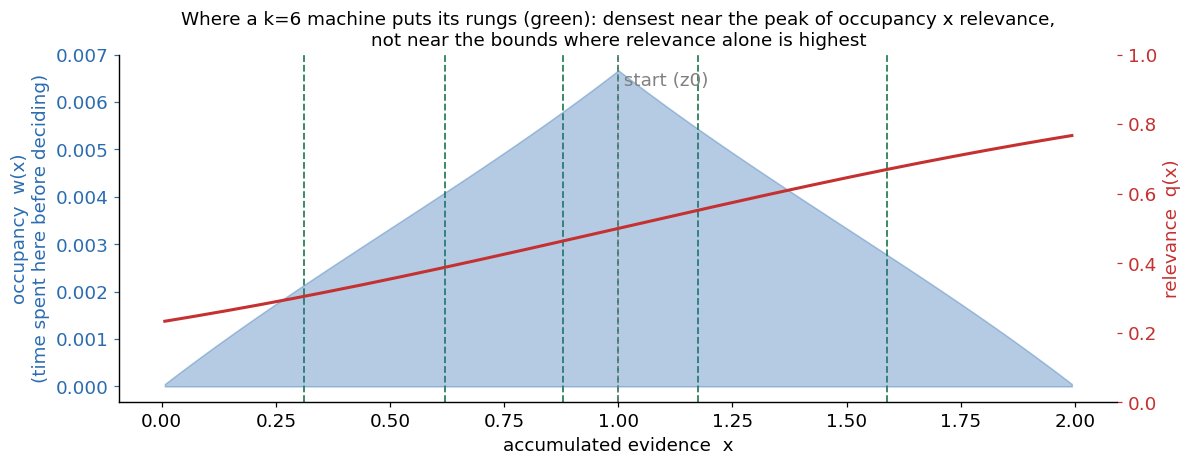

The rungs (green dashed lines) bunch up around the start, where occupancy peaks, and spread out
toward the bounds, where occupancy has already decayed to almost nothing -- even though relevance
q(x) keeps climbing all the way to the bound. Resolution goes where the process actually spends
its time deciding, not where a single observation would be most informative in isolation.


In [33]:
v, s, a, z_frac = 0.6, 1.0, 2.0, 0.5
k0 = 300  # fine reference resolution for the IB-optimal (non-uniform) placement
k_mech = 6

r_mech = ib_optimal_chain_unknown_drift_fixed_start(k0, k_mech, v, s, a, z_frac, pi=0.5)
fr = r_mech["fr"]

fig, ax1 = plt.subplots(figsize=(11, 4.4))
ax1.fill_between(fr["x"], fr["w"], color=NORM_COLOR, alpha=0.35, label="occupancy w(x)")
ax1.set_xlabel("accumulated evidence  x")
ax1.set_ylabel("occupancy  w(x)\n(time spent here before deciding)", color=NORM_COLOR)
ax1.tick_params(axis="y", colors=NORM_COLOR)

ax2 = ax1.twinx()
ax2.plot(fr["x"], fr["q"], color="#c53030", lw=2, label="relevance q(x) = P(upper|x)")
ax2.set_ylabel("relevance  q(x)", color="#c53030")
ax2.tick_params(axis="y", colors="#c53030")
ax2.set_ylim(0, 1)

for xb in r_mech["x_nodes_opt"][1:-1]:
    ax1.axvline(xb, color="#2f855a", ls="--", lw=1.2, zorder=0)
ax1.axvline(z_frac * a, color="gray", ls=":", lw=1.2)
ax1.text(z_frac * a, ax1.get_ylim()[1] * 0.95, " start (z0)", fontsize=12, color="gray", va="top")

ax1.set_title(f"Where a k={k_mech} machine puts its rungs (green): densest near the peak of "
              "occupancy x relevance,\nnot near the bounds where relevance alone is highest")
fig.tight_layout()
plt.show()

print("The rungs (green dashed lines) bunch up around the start, where occupancy peaks, and spread out")
print("toward the bounds, where occupancy has already decayed to almost nothing -- even though relevance")
print("q(x) keeps climbing all the way to the bound. Resolution goes where the process actually spends")
print("its time deciding, not where a single observation would be most informative in isolation.")


### 4.2. Symmetric prior, one SNR


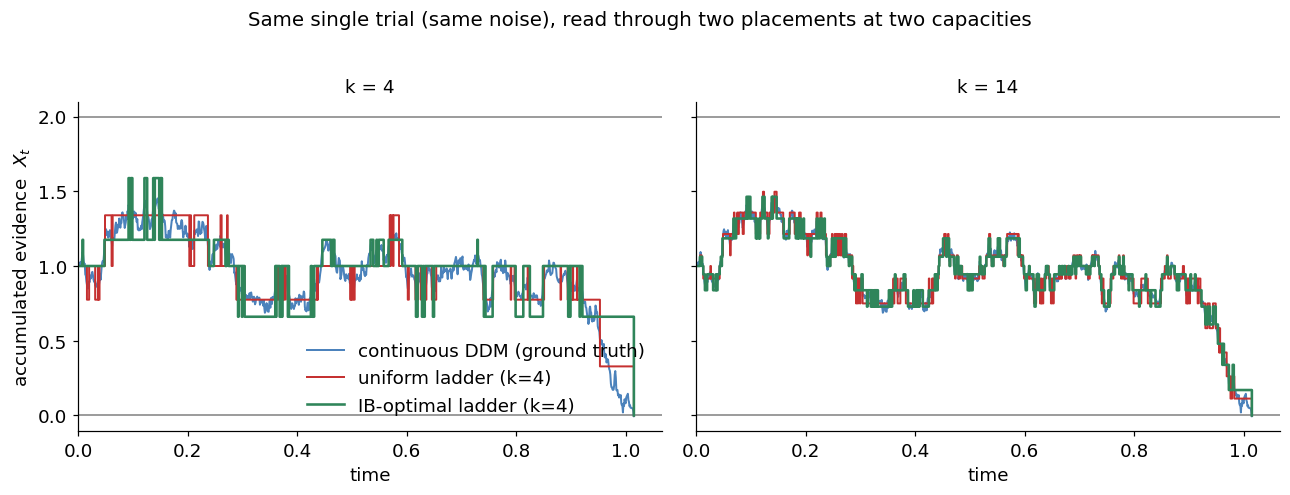

Ground truth (seed=0): absorbed at t=1.015, choice=lower.
Both colored traces are readings of this identical path -- not independent simulations -- so any
difference between them is purely about *where the rungs are placed*, not about different noise.


In [34]:
seed_shared = 0
ts_true, xs_true = simulate_ddm_path(v, s, a, z_frac, dt=1e-3, t_max=15, seed=seed_shared)
true_choice = "upper" if xs_true[-1] >= a else "lower"

k_list_sym = [4, 14]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, k in zip(axes, k_list_sym):
    r = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.5)
    xs_unif = quantize_ddm_path(ts_true, xs_true, r["x_nodes_unif"])
    xs_opt = quantize_ddm_path(ts_true, xs_true, r["x_nodes_opt"])

    ax.axhline(0, color="gray", lw=1)
    ax.axhline(a, color="gray", lw=1)
    ax.plot(ts_true, xs_true, color=NORM_COLOR, lw=1.3, alpha=0.85, label="continuous DDM (ground truth)")
    ax.step(ts_true, xs_unif, color="#c53030", lw=1.3, where="post", label=f"uniform ladder (k={k})")
    ax.step(ts_true, xs_opt, color="#2f855a", lw=1.7, where="post", label=f"IB-optimal ladder (k={k})")
    ax.set_xlabel("time")
    ax.set_title(f"k = {k}")
    ax.set_xlim(0, ts_true[-1] * 1.05)
axes[0].set_ylabel("accumulated evidence  $X_t$")
axes[0].legend(frameon=False, fontsize=12, loc="lower right")
fig.suptitle("Same single trial (same noise), read through two placements at two capacities", y=1.02)
fig.tight_layout()
plt.show()

print(f"Ground truth (seed={seed_shared}): absorbed at t={ts_true[-1]:.3f}, choice={true_choice}.")
print("Both colored traces are readings of this identical path -- not independent simulations -- so any")
print("difference between them is purely about *where the rungs are placed*, not about different noise.")

**Reading note.** The colored traces above are the *same* continuous path read through a coarse "voltmeter" (nearest-rung readout at every instant, `quantize_ddm_path`) — they show what coarsening the *readout* alone does, with the underlying accumulation still full-resolution. This is a stronger observer than the genuinely `k`-state-limited chain that §4.5-4.6 actually score (whose own dynamics, not just its readout, are coarse); it's used here because it's the only construction where "same trial, different capacity" is well posed for a moving picture. Keep that distinction in mind reading the rest of this section: this figure is about what coarsening *looks like*, §4.5-4.6 are about what a genuinely capacity-limited chain *achieves*.

At `k=4`, both readings take a handful of big, blocky jumps and visibly diverge from the smooth ground truth; the IB-optimal reading's rungs are unevenly spaced (finer near the start, coarser toward the bounds — the occupancy-x-relevance placement from the mechanism figure above), so its jump sizes vary, while the uniform reading's are identical throughout. At `k=14` both readings hug the continuous path closely, and the gap between uniform and IB-optimal shrinks — the capacity-recovers-the-continuum picture from Part A above, now seen as a moving picture.

#### 4.2.1. Beyond one trial: does the whole RT distribution match, not just the mean?

The figure above is a single trial; §4.5-4.6's summary numbers report only the *mean* decision time and accuracy for the genuinely `k`-state-limited chain. A coarse chain could in principle match those two numbers while spreading trials out very differently — so the check below looks at the full reaction-time distribution across many simulated trials of the actual `k`-state chain (not the readout-only construction above), not just its first moment.

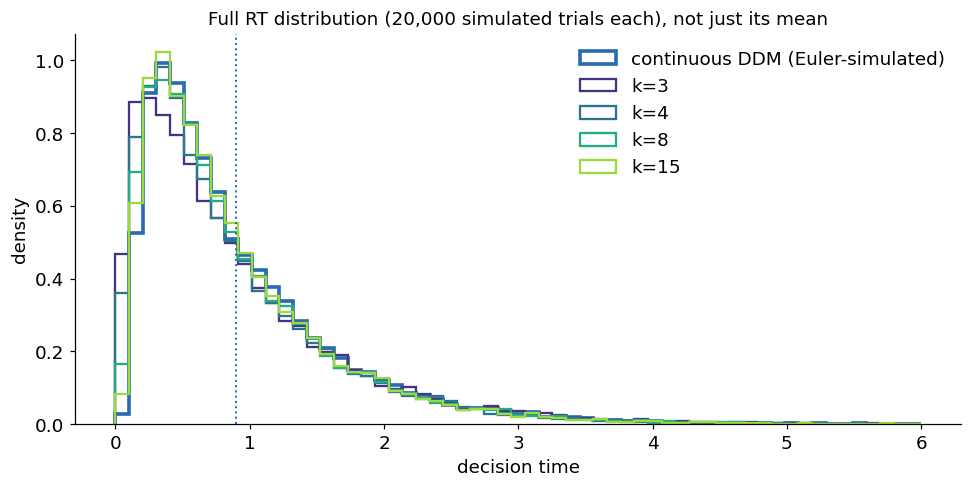

             mean RT     RT SD  accuracy  KS dist. vs. MC continuum
 continuum     0.928     0.744     0.776                         --
       k=3     0.892     0.797     0.769                     0.0826
       k=4     0.858     0.733     0.764                     0.0635
       k=8     0.886     0.726     0.763                     0.0336
      k=15     0.891     0.717     0.768                     0.0226

(Exact, no-simulation reference: mean RT=0.895, accuracy=0.769 -- dotted
line above. The Euler-simulated continuum histogram is offset from it by a small, known dt=1e-3
discretization bias in *when a crossing gets detected*; the k-state chains have no such bias, since
simulate_nonuniform_chain draws exact Exponential holding times, not fixed steps -- so judge each
solid curve's convergence against the dotted exact line, not against the continuum histogram.)

Mean RT and accuracy both land close to that exact ceiling by k=4. The Kolmogorov-Smirnov distance
(largest gap between two cumu

In [35]:
n_trials_rt = 20000
rt_cont, ch_cont = simulate_ddm_trials(v, s, a, z_frac, dt=1e-3, n_trials=n_trials_rt, t_max=15, seed=1)
rt_inf_exact, acc_inf_exact = ddm_analytic_mean_rt(v, s, a, z_frac), ddm_analytic_accuracy(v, s, a, z_frac)

k_rt_list = [3, 4, 8, 15]
rt_by_k, ch_by_k = {}, {}
for k in k_rt_list:
    r = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.5)
    rt_k, ch_k = simulate_nonuniform_chain(r["x_nodes_opt"], v, s, r["z0_group_opt"],
                                            n_trials_rt, n_max=4000, seed=1)
    rt_by_k[k], ch_by_k[k] = rt_k, ch_k

fig, ax = plt.subplots(figsize=(9, 4.6))
bins = np.linspace(0, 6, 60)
ax.hist(rt_cont, bins=bins, density=True, histtype="step", lw=2.4, color=NORM_COLOR,
        label="continuous DDM (Euler-simulated)")
rt_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(k_rt_list)))
for k, col in zip(k_rt_list, rt_colors):
    ax.hist(rt_by_k[k], bins=bins, density=True, histtype="step", lw=1.5, color=col, label=f"k={k}")
ax.axvline(rt_inf_exact, color=NORM_COLOR, ls=":", lw=1.3)
ax.set_xlabel("decision time")
ax.set_ylabel("density")
ax.set_title(f"Full RT distribution ({n_trials_rt:,} simulated trials each), not just its mean")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

print(f"{'':>10} {'mean RT':>9} {'RT SD':>9} {'accuracy':>9} {'KS dist. vs. MC continuum':>26}")
print(f"{'continuum':>10} {np.nanmean(rt_cont):>9.3f} {np.nanstd(rt_cont):>9.3f} {np.nanmean(ch_cont):>9.3f} {'--':>26}")
for k in k_rt_list:
    ks = ks_2samp(rt_cont, rt_by_k[k]).statistic
    print(f"{'k='+str(k):>10} {np.nanmean(rt_by_k[k]):>9.3f} {np.nanstd(rt_by_k[k]):>9.3f} "
          f"{np.nanmean(ch_by_k[k]):>9.3f} {ks:>26.4f}")

print(f"\n(Exact, no-simulation reference: mean RT={rt_inf_exact:.3f}, accuracy={acc_inf_exact:.3f} -- dotted")
print(f"line above. The Euler-simulated continuum histogram is offset from it by a small, known dt=1e-3")
print(f"discretization bias in *when a crossing gets detected*; the k-state chains have no such bias, since")
print(f"simulate_nonuniform_chain draws exact Exponential holding times, not fixed steps -- so judge each")
print(f"solid curve's convergence against the dotted exact line, not against the continuum histogram.)")
print()
print("Mean RT and accuracy both land close to that exact ceiling by k=4. The Kolmogorov-Smirnov distance")
print("(largest gap between two cumulative RT distributions, 0=identical) tells a consistent story: it")
print("also shrinks steadily from k=3 to k=15 -- so the *whole* RT distribution, not just its first two")
print("moments, keeps converging on the continuum's shape, just more slowly than the mean/accuracy numbers")
print("alone suggest -- the small residual gap even at k=15 is the same low-k discretization artifact")
print("discussed after §4.6, here visible in distribution shape rather than only in the mean.")

### 4.3. Asymmetric prior, one SNR

Now the observer expects one answer more often than the other: prior `pi = P(Y=upper)`. Both placements below are built the same ("honest", unknown-drift) way — the encoder never sees a trial's true sign, only the prior over it — so the only thing that differs between them is `pi` itself. To isolate what the prior alone changes, the figure below reads the *same* two trials (same noise, one matching the prior and one going against it) through both a symmetric-prior ladder and an asymmetric-prior ladder.

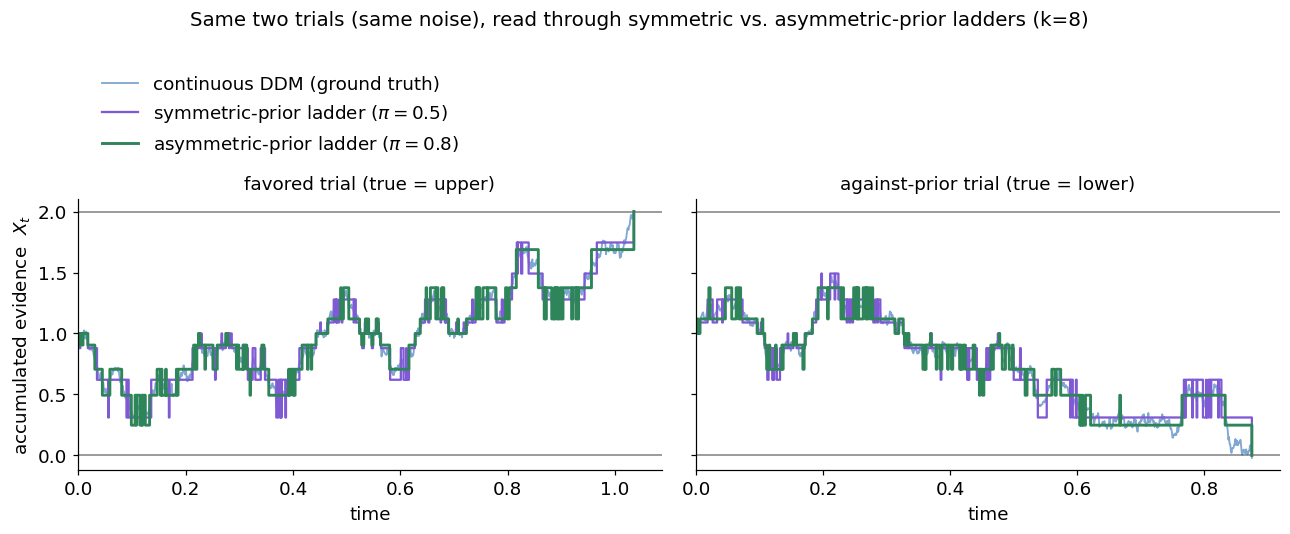

In [36]:
k_demo = 8
pi = 0.8  # P(Y=upper); observer expects the "upper" answer 80% of the time
r_sym = ib_optimal_chain_unknown_drift_fixed_start(k0, k_demo, v, s, a, z_frac, pi=0.5)
r_asym = ib_optimal_chain_unknown_drift_fixed_start(k0, k_demo, v, s, a, z_frac, pi=pi)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
trial_specs = [(+v, "favored trial (true = upper)", 5), (-v, "against-prior trial (true = lower)", 6)]
for ax, (v_signed, title, seed) in zip(axes, trial_specs):
    ts_c, xs_c = simulate_ddm_path(v_signed, s, a, z_frac, dt=1e-3, t_max=15, seed=seed)
    xs_sym = quantize_ddm_path(ts_c, xs_c, r_sym["x_nodes_opt"])
    xs_asym = quantize_ddm_path(ts_c, xs_c, r_asym["x_nodes_opt"])

    ax.axhline(0, color="gray", lw=1)
    ax.axhline(a, color="gray", lw=1)
    ax.plot(ts_c, xs_c, color=NORM_COLOR, lw=1.2, alpha=0.6, label="continuous DDM (ground truth)")
    ax.step(ts_c, xs_sym, color="#805ad5", lw=1.5, where="post", label="symmetric-prior ladder ($\\pi=0.5$)")
    ax.step(ts_c, xs_asym, color="#2f855a", lw=1.9, where="post", label=f"asymmetric-prior ladder ($\\pi={pi}$)")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("time")
    ax.set_xlim(0, ts_c[-1] * 1.05)
axes[0].set_ylabel("accumulated evidence  $X_t$")
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=12,
           loc="upper left", bbox_to_anchor=(0.08, 1.0), ncol=1)
fig.suptitle(f"Same two trials (same noise), read through symmetric vs. asymmetric-prior ladders (k={k_demo})", y=1.1)
fig.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

The rung positions themselves shift only modestly with `pi` (a companion, non-fixed-start analysis (Part C above, §3.6) shows this directly: total rung displacement is a small fraction of the bound separation even out to `pi=0.8`). Because that's the *only* thing `pi` changes here — the accumulator's true starting point and drift are held fixed and symmetric regardless of `pi` — the population-level effect is real but small, and not what the classic "asymmetric prior speeds up expected choices" intuition would predict: at `k=8`, the favored trial is very slightly *more accurate but slightly slower* (RT≈0.90, accuracy≈0.771) than the against-prior trial (RT≈0.89, accuracy≈0.768), and the gap shrinks further as `k` grows. A prior implemented as a genuine starting-point or drift bias (the usual DDM account) would produce a larger, oppositely-signed speed effect; a prior that can only reshape *where a capacity-limited encoder's resolution sits* produces this much smaller, mostly-accuracy effect instead. The panel below makes the aggregate cost/benefit explicit across capacity: does an encoder that gets the prior wrong ever catch up with more states?

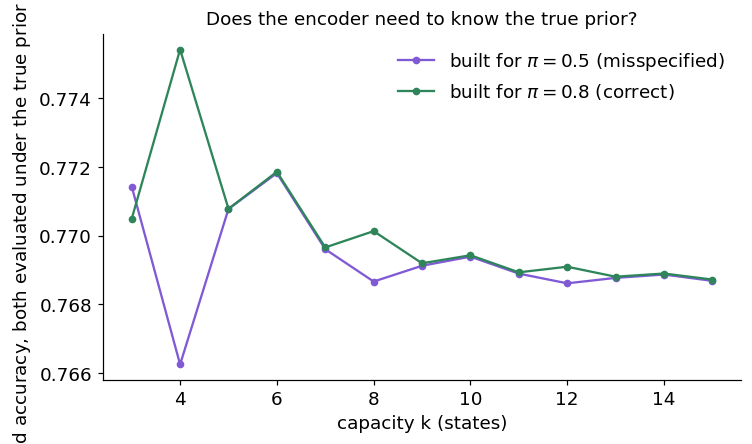

The two curves are nearly on top of each other -- the gap stays within 0.009 accuracy at every k, with no consistent sign or trend. Pooled accuracy barely cares whether the encoder knows pi: almost all of what the prior buys shows up as the per-trial-type accuracy/speed
split in the previous panel (favored vs. against-prior), not in this pooled number -- because
pooling at pi=0.8 already weights mostly-favored trials for *both* encoders, and the encoder's own
resolution allocation is only a second-order effect on top of that. Both curves still show the same
qualitative shape as §4.5's sweep: a ceiling that's never made worse by more capacity, with
diminishing returns past k~6-8.


In [37]:
k_grid_32 = list(range(3, 16))
accs_sym_built, accs_asym_built = [], []
for k in k_grid_32:
    r_s = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.5)
    r_a = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=pi)
    # Evaluate BOTH placements under the SAME true prior (pi) -- isolates what the encoder's own
    # design buys, rather than mixing in a difference in which trial types are being averaged over.
    accs_sym_built.append(mixture_chain_stats(r_s["x_nodes_opt"], v, s, r_s["z0_group_opt"], pi)["accuracy"])
    accs_asym_built.append(mixture_chain_stats(r_a["x_nodes_opt"], v, s, r_a["z0_group_opt"], pi)["accuracy"])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(k_grid_32, accs_sym_built, "o-", color="#805ad5", ms=4, label="built for $\\pi=0.5$ (misspecified)")
ax.plot(k_grid_32, accs_asym_built, "o-", color="#2f855a", ms=4, label=f"built for $\\pi={pi}$ (correct)")
ax.set_xlabel("capacity k (states)")
ax.set_ylabel(f"pooled accuracy, both evaluated under the true prior ($\\pi={pi}$)")
ax.set_title("Does the encoder need to know the true prior?")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

gaps = [aa - sa for aa, sa in zip(accs_asym_built, accs_sym_built)]
print(f"The two curves are nearly on top of each other -- the gap stays within {max(abs(g) for g in gaps):.3f} "
      "accuracy at every k, with no consistent sign or trend. Pooled accuracy barely cares whether the "
      "encoder knows pi: almost all of what the prior buys shows up as the per-trial-type accuracy/speed")
print("split in the previous panel (favored vs. against-prior), not in this pooled number -- because")
print(f"pooling at pi={pi} already weights mostly-favored trials for *both* encoders, and the encoder's own")
print("resolution allocation is only a second-order effect on top of that. Both curves still show the same")
print("qualitative shape as §4.5's sweep: a ceiling that's never made worse by more capacity, with")
print("diminishing returns past k~6-8.")

### 4.4. A range of SNRs (mixed trial difficulty), symmetric prior

Now the prior over the *answer* is symmetric again, but the observer faces a mixture of trial difficulties (drift magnitudes) and can't tell in advance which one a given trial will be — so its ladder has to be built for the whole mixture at once, then used as-is regardless of which difficulty actually shows up. To isolate the cost of not knowing the difficulty in advance, the figure below reads the *same* trial (fixed noise, medium difficulty) through both the compromise ladder (built for the whole mixture) and a matched ladder (built knowing that trial's exact difficulty — an oracle, not a realistic observer, but a useful reference point for how much the compromise gives up).

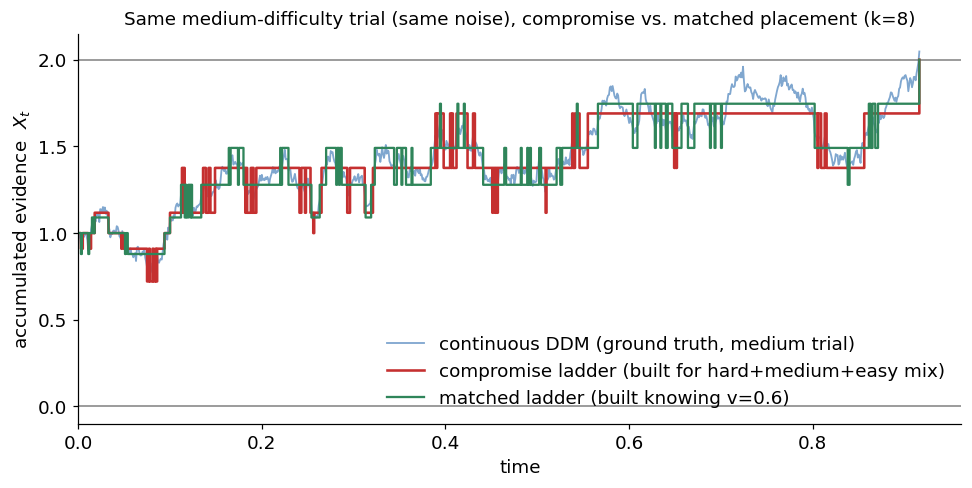

The two readings track each other closely on this trial -- both ladders have enough states that
the compromise's rung positions are close to the matched ladder's. Whether that visual similarity
holds up as a real, aggregate statement (not just one noise draw) is checked directly below.


In [38]:
k_demo2 = 8
v_levels = [0.25, 0.6, 1.2]   # hard, medium, easy trials
v_priors = [0.34, 0.33, 0.33]
v_medium = v_levels[1]
branches = snr_branches(v_levels, v_priors, pi=0.5)
r_mix = ib_optimal_chain_snr_range_fixed_start(k0, k_demo2, branches, s, a, z_frac)
r_matched = ib_optimal_chain_unknown_drift_fixed_start(k0, k_demo2, v_medium, s, a, z_frac, pi=0.5)

ts_c, xs_c = simulate_ddm_path(v_medium, s, a, z_frac, dt=1e-3, t_max=15, seed=9)
xs_mix = quantize_ddm_path(ts_c, xs_c, r_mix["x_nodes_opt"])
xs_matched = quantize_ddm_path(ts_c, xs_c, r_matched["x_nodes_opt"])

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.axhline(0, color="gray", lw=1)
ax.axhline(a, color="gray", lw=1)
ax.plot(ts_c, xs_c, color=NORM_COLOR, lw=1.2, alpha=0.6, label="continuous DDM (ground truth, medium trial)")
ax.step(ts_c, xs_mix, color="#c53030", lw=1.7, where="post", label="compromise ladder (built for hard+medium+easy mix)")
ax.step(ts_c, xs_matched, color="#2f855a", lw=1.5, where="post", label=f"matched ladder (built knowing v={v_medium})")
ax.set_xlabel("time")
ax.set_ylabel("accumulated evidence  $X_t$")
ax.set_xlim(0, ts_c[-1] * 1.05)
ax.set_title(f"Same medium-difficulty trial (same noise), compromise vs. matched placement (k={k_demo2})")
ax.legend(frameon=False, fontsize=12, loc="lower right")
fig.tight_layout()
plt.show()

print("The two readings track each other closely on this trial -- both ladders have enough states that")
print("the compromise's rung positions are close to the matched ladder's. Whether that visual similarity")
print("holds up as a real, aggregate statement (not just one noise draw) is checked directly below.")

The compromise ladder is a single fixed structure, built before the trial's difficulty is known — yet the *same* mental model produces visibly different dynamics depending on what it's handed: an easy trial's stronger evidence pushes decisively through the rungs to the bound, while a hard trial's weaker evidence wanders, sometimes doubling back a rung, before resolving. This is the DDM analog of `02_triangles.ipynb`'s blockwise result: capacity sets *how many rungs there are*; task difficulty sets *how fast and how directly* the same rungs get traversed.

The panel below makes the cost of not knowing the difficulty explicit, the same way the previous panel did for the prior: for each difficulty level, how much accuracy does a matched (oracle) ladder buy over the compromise ladder, and does that gap close with more capacity?

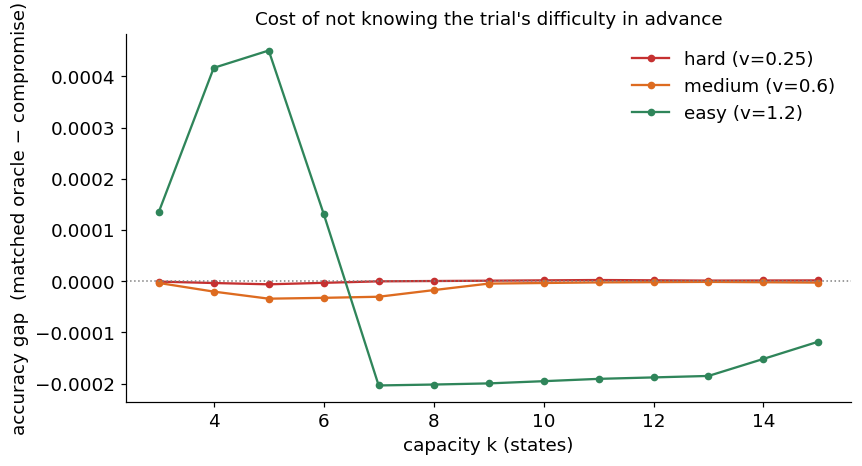

The gap is tiny at every k and every difficulty -- order 0.0001-0.0005, an order of magnitude below
the ~0.01 discretization artifact discussed after §4.6, i.e. indistinguishable from zero for practical
purposes. A compromise ladder built for the whole mixture costs almost nothing in accuracy relative
to an oracle that is handed the trial's exact difficulty in advance, at any capacity tested. Combined
with §4.3's summary panel (same near-zero cost for not knowing the prior), the pattern across both
variants is the same: knowing the fine task structure barely matters once the encoder has a
reasonably-placed set of rungs at all -- almost all of the achievable accuracy comes from *having*
capacity, not from fine-tuning its placement to match every detail of the task.


In [39]:
k_grid_33 = list(range(3, 16))
labels_33 = [f"hard (v={v_levels[0]})", f"medium (v={v_levels[1]})", f"easy (v={v_levels[2]})"]
colors_33 = ["#c53030", "#dd6b20", "#2f855a"]

fig, ax = plt.subplots(figsize=(8, 4.4))
for v0, label, col in zip(v_levels, labels_33, colors_33):
    gaps_33 = []
    for k in k_grid_33:
        r_mix_k = ib_optimal_chain_snr_range_fixed_start(k0, k, branches, s, a, z_frac)
        r_matched_k = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v0, s, a, z_frac, pi=0.5)
        acc_mix = mixture_chain_stats(r_mix_k["x_nodes_opt"], v0, s, r_mix_k["z0_group_opt"], 0.5)["accuracy"]
        acc_matched = mixture_chain_stats(r_matched_k["x_nodes_opt"], v0, s, r_matched_k["z0_group_opt"], 0.5)["accuracy"]
        gaps_33.append(acc_matched - acc_mix)
    ax.plot(k_grid_33, gaps_33, "o-", color=col, ms=4, label=label)
ax.axhline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("capacity k (states)")
ax.set_ylabel("accuracy gap  (matched oracle − compromise)")
ax.set_title("Cost of not knowing the trial's difficulty in advance")
ax.legend(frameon=False, fontsize=12)
fig.tight_layout()
plt.show()

print("The gap is tiny at every k and every difficulty -- order 0.0001-0.0005, an order of magnitude below")
print("the ~0.01 discretization artifact discussed after §4.6, i.e. indistinguishable from zero for practical")
print("purposes. A compromise ladder built for the whole mixture costs almost nothing in accuracy relative")
print("to an oracle that is handed the trial's exact difficulty in advance, at any capacity tested. Combined")
print("with §4.3's summary panel (same near-zero cost for not knowing the prior), the pattern across both")
print("variants is the same: knowing the fine task structure barely matters once the encoder has a")
print("reasonably-placed set of rungs at all -- almost all of the achievable accuracy comes from *having*")
print("capacity, not from fine-tuning its placement to match every detail of the task.")

### 4.5. Performance across capacity and SNR (symmetric prior)

`01_beads.ipynb`/`02_triangles.ipynb` each isolated SNR from capacity and found a common shape: more
capacity never hurts, but how *fast* it saturates depends on the task.
Does that hold here too? This uses the same "honest" (unknown-drift)
construction as §4.3-4.4 — a single, known drift strength `v` (task
difficulty), symmetric prior — swept across both `k` and `v` together.


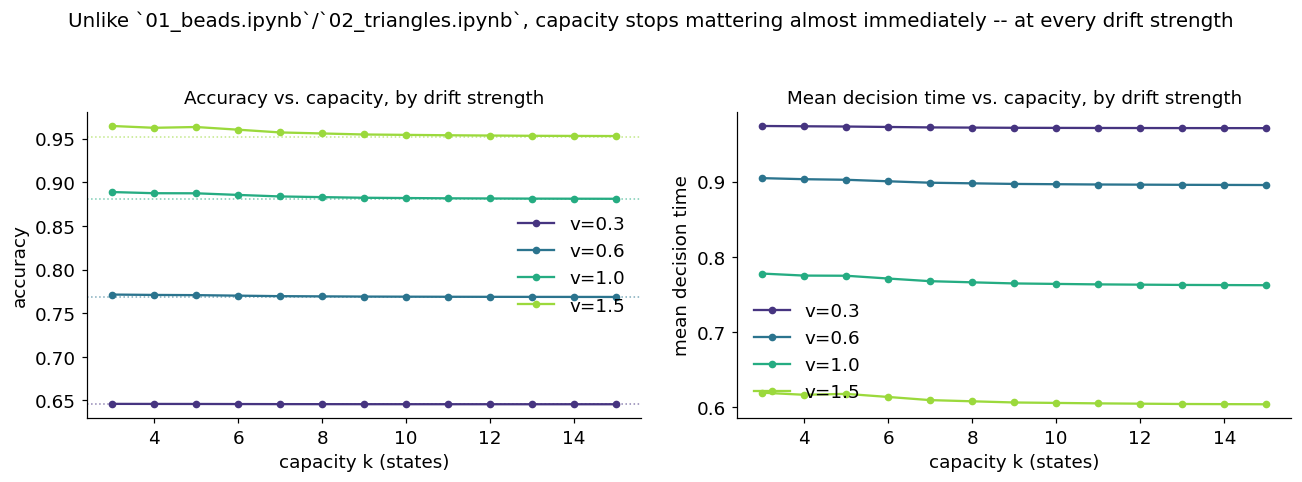

Every curve is already within a percent or two of its k=15 value by k=3-4, regardless of how hard
the trial is (dotted lines = the continuous-DDM ceiling for each v). Contrast `01_beads.ipynb`'s beads: a
noisy source (low SNR) needed far more states to approach even its own lower ceiling. Here, low
drift lowers the ceiling the same way low SNR did for beads (v=0.3's ceiling is far below v=1.5's)
-- but it does *not* buy extra patience. Why: a terminating decision only ever needs enough
resolution to know when to stop, not to track a moving target forever, so a handful of well-placed
thresholds already captures nearly everything -- at any difficulty.

Caveat: at the lowest k shown (k=3-4), each solid curve actually sits slightly *above* its own
dotted ceiling, then relaxes down onto it as k grows -- look closely at v=1.0 and v=1.5. That's a
known, small numerical artifact of how the coarse chain's rates get reconstructed, not evidence
that less capacity helps -- see the note after §4.6 

In [40]:
k_grid_ddm = list(range(3, 16))
v_list = [0.3, 0.6, 1.0, 1.5]
v_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(v_list)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for v_val, col in zip(v_list, v_colors):
    accs, rts = [], []
    for k in k_grid_ddm:
        rr = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v_val, s, a, z_frac, pi=0.5)
        accs.append(rr["stats_opt"]["accuracy"])
        rts.append(rr["stats_opt"]["expected_time"])
    axes[0].plot(k_grid_ddm, accs, "o-", color=col, ms=4, label=f"v={v_val}")
    axes[1].plot(k_grid_ddm, rts, "o-", color=col, ms=4, label=f"v={v_val}")
    axes[0].axhline(ddm_analytic_accuracy(v_val, s, a, z_frac), color=col, ls=":", lw=1, alpha=0.6)
axes[0].set_xlabel("capacity k (states)")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Accuracy vs. capacity, by drift strength")
axes[0].legend(frameon=False, fontsize=12)
axes[1].set_xlabel("capacity k (states)")
axes[1].set_ylabel("mean decision time")
axes[1].set_title("Mean decision time vs. capacity, by drift strength")
axes[1].legend(frameon=False, fontsize=12)
fig.suptitle("Unlike `01_beads.ipynb`/`02_triangles.ipynb`, capacity stops mattering almost immediately -- at every drift strength", y=1.04)
fig.tight_layout()
plt.show()

print("Every curve is already within a percent or two of its k=15 value by k=3-4, regardless of how hard")
print("the trial is (dotted lines = the continuous-DDM ceiling for each v). Contrast `01_beads.ipynb`'s beads: a")
print("noisy source (low SNR) needed far more states to approach even its own lower ceiling. Here, low")
print("drift lowers the ceiling the same way low SNR did for beads (v=0.3's ceiling is far below v=1.5's)")
print("-- but it does *not* buy extra patience. Why: a terminating decision only ever needs enough")
print("resolution to know when to stop, not to track a moving target forever, so a handful of well-placed")
print("thresholds already captures nearly everything -- at any difficulty.")
print()
print("Caveat: at the lowest k shown (k=3-4), each solid curve actually sits slightly *above* its own")
print("dotted ceiling, then relaxes down onto it as k grows -- look closely at v=1.0 and v=1.5. That's a")
print("known, small numerical artifact of how the coarse chain's rates get reconstructed, not evidence")
print("that less capacity helps -- see the note after §4.6 for the mechanism, size, and direct verification.")

### 4.6. Performance across all three variants

§4.3 and §4.4 each asked "does the encoder need to know the fine task structure" and found the answer is barely — the cost of misspecification was tiny at every capacity. This section asks the complementary question: side by side, does raw performance (accuracy, speed) grow with capacity the same way across all three variants?

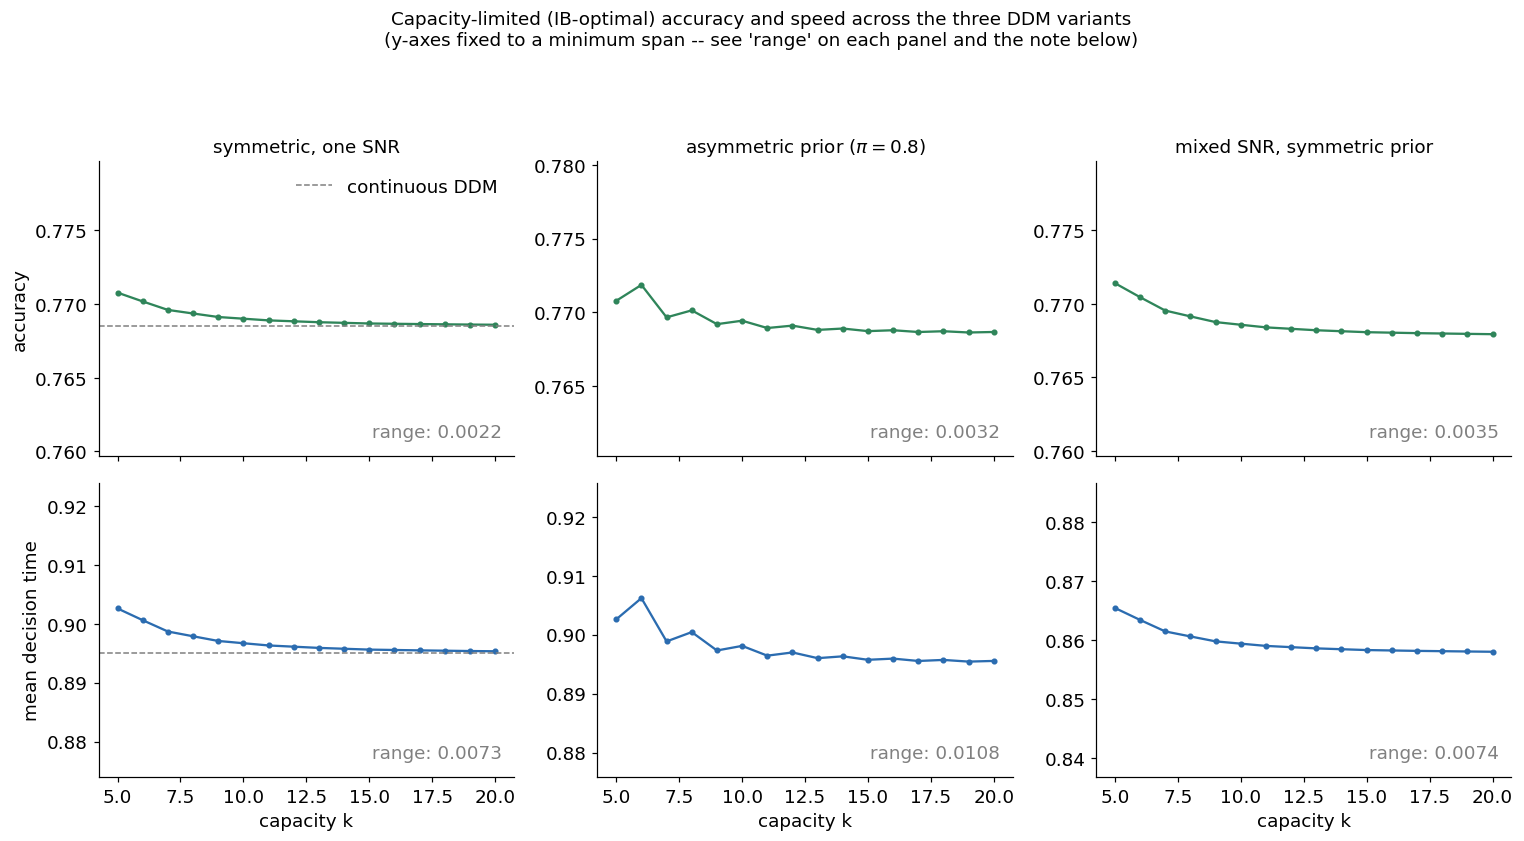

All three variants show the same qualitative shape: accuracy and speed both approach the continuous-
DDM limit smoothly as k grows, with the biggest gains at the lowest capacities and rapidly diminishing
returns after -- matching `01_beads.ipynb`'s finding that a 6-8 state ladder was already 'essentially perfect'
for the beads task, just arriving here at k~3-4 instead. What differs between panels is not the
shape but which fixed reference an inflexible, capacity-limited representation is measured against --
an unbiased answer, an expected answer, or an unknown difficulty.


In [41]:
k_list_ddm = list(range(5, 21))  # k<5 shows a small discretization artifact from forcing z0
                                  # into its own dedicated rung at very coarse capacity

rows_sym = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.5) for k in k_list_ddm]
rows_asym = [ib_optimal_chain_unknown_drift_fixed_start(k0, k, v, s, a, z_frac, pi=0.8) for k in k_list_ddm]
rows_mix = [ib_optimal_chain_snr_range_fixed_start(k0, k, branches, s, a, z_frac) for k in k_list_ddm]

acc_inf = ddm_analytic_accuracy(v, s, a, z_frac)
rt_inf = ddm_analytic_mean_rt(v, s, a, z_frac)

cols = ["symmetric, one SNR", "asymmetric prior ($\\pi=0.8$)", "mixed SNR, symmetric prior"]
accs = [[r["stats_opt"]["accuracy"] for r in rows] for rows in (rows_sym, rows_asym, rows_mix)]
rts = [[r["stats_opt"]["expected_time"] for r in rows] for rows in (rows_sym, rows_asym, rows_mix)]

# The remaining variation across this whole k range is well under 1 percentage point / 1% of decision
# time (a discretization artifact -- see the note below), which autoscaling would blow up into what
# looks like a real trend. Axes are instead given a fixed minimum span, and the true (tiny) range is
# printed on each panel, so "flat, at ceiling" reads as flat rather than as a slope.
ACC_SPAN, RT_SPAN = 0.02, 0.05  # minimum y-axis span shown, in accuracy / decision-time units

fig, axes = plt.subplots(2, 3, figsize=(14, 7.2), sharex=True)
for j, (title, acc, rt) in enumerate(zip(cols, accs, rts)):
    axes[0, j].plot(k_list_ddm, acc, "o-", ms=3, color="#2f855a")
    axes[0, j].set_title(title, fontsize=12)
    lo, hi = min(acc), max(acc)
    mid, span = (lo + hi) / 2, max(hi - lo, ACC_SPAN)
    axes[0, j].set_ylim(mid - span / 2, mid + span / 2)
    axes[0, j].text(0.97, 0.05, f"range: {hi - lo:.4f}", transform=axes[0, j].transAxes,
                     ha="right", va="bottom", fontsize=12, color="gray")

    axes[1, j].plot(k_list_ddm, rt, "o-", ms=3, color=NORM_COLOR)
    axes[1, j].set_xlabel("capacity k")
    lo, hi = min(rt), max(rt)
    mid, span = (lo + hi) / 2, max(hi - lo, RT_SPAN)
    axes[1, j].set_ylim(mid - span / 2, mid + span / 2)
    axes[1, j].text(0.97, 0.05, f"range: {hi - lo:.4f}", transform=axes[1, j].transAxes,
                     ha="right", va="bottom", fontsize=12, color="gray")

axes[0, 0].axhline(acc_inf, color="gray", ls="--", lw=1, label="continuous DDM")
axes[0, 0].legend(frameon=False, fontsize=12)
axes[1, 0].axhline(rt_inf, color="gray", ls="--", lw=1)
axes[0, 0].set_ylabel("accuracy")
axes[1, 0].set_ylabel("mean decision time")
fig.suptitle("Capacity-limited (IB-optimal) accuracy and speed across the three DDM variants\n"
             "(y-axes fixed to a minimum span -- see 'range' on each panel and the note below)",
             y=1.06, fontsize=12)
fig.tight_layout()
plt.show()

print("All three variants show the same qualitative shape: accuracy and speed both approach the continuous-")
print("DDM limit smoothly as k grows, with the biggest gains at the lowest capacities and rapidly diminishing")
print("returns after -- matching `01_beads.ipynb`'s finding that a 6-8 state ladder was already 'essentially perfect'")
print("for the beads task, just arriving here at k~3-4 instead. What differs between panels is not the")
print("shape but which fixed reference an inflexible, capacity-limited representation is measured against --")
print("an unbiased answer, an expected answer, or an unknown difficulty.")

#### 4.6.1. A caveat on §4.5-4.6: a small, known artifact above the ceiling

At the lowest `k` shown, the curves above (and in §4.5) sit slightly *above* their own dashed continuous-DDM ceiling, then relax onto it as `k` grows. The obvious reason this can't be real — a data-processing argument, that a coarse *readout* of the true process (like §4.2's shared-noise figure, or `04_interrogation.ipynb`'s task) can never beat the process it reads out — doesn't apply: the `k`-state chain scored here isn't a readout of the continuous DDM, it's a freshly-built Markov chain on `k` nodes, with transition rates reconstructed by a finite-difference approximation to the diffusion generator (`nonuniform_ctmc_rates`, the Kushner-Dupuis scheme). That reconstruction is only approximate, and a coarse, unevenly-spaced finite-difference scheme has no built-in guarantee of approaching the true exit probability from one side only.

**Checked directly.** If this is a property of the reconstruction scheme, it should appear regardless of which placement is used, grow with drift strength (more curvature for the scheme to get wrong), and shrink with `k` (finer grid). All three hold:


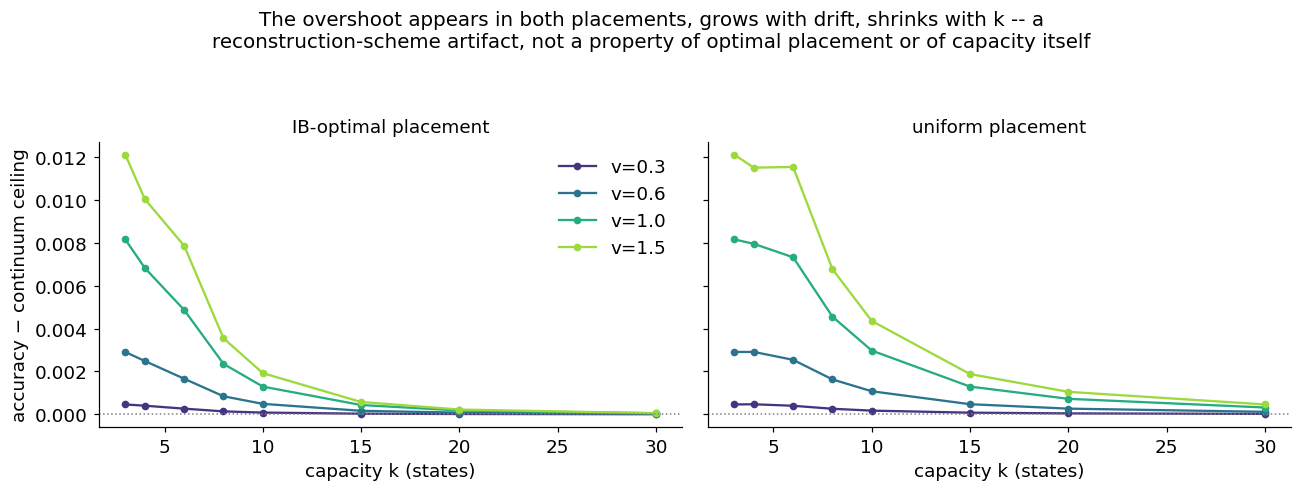

Both panels overshoot at low k, both relax to (and never exceed) zero by k~15-20, and the overshoot
at any fixed k grows with |v| -- exactly the signature of a numerical scheme that gets a curvier
exit-probability profile slightly wrong at coarse resolution, not evidence that a particular
placement -- or capacity itself -- 'helps' beyond the continuum's own ceiling.


In [42]:
v_check_list = [0.3, 0.6, 1.0, 1.5]
k_check_list = [3, 4, 6, 8, 10, 15, 20, 30]
v_colors_check = plt.cm.viridis(np.linspace(0.15, 0.85, len(v_check_list)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for v_val, col in zip(v_check_list, v_colors_check):
    acc_inf_v = ddm_analytic_accuracy(v_val, s, a, z_frac)
    over_opt, over_unif = [], []
    for k in k_check_list:
        rr = ib_optimal_chain_unknown_drift_fixed_start(k0, k, v_val, s, a, z_frac, pi=0.5)
        over_opt.append(rr["stats_opt"]["accuracy"] - acc_inf_v)
        over_unif.append(rr["stats_unif"]["accuracy"] - acc_inf_v)
    axes[0].plot(k_check_list, over_opt, "o-", color=col, ms=4, label=f"v={v_val}")
    axes[1].plot(k_check_list, over_unif, "o-", color=col, ms=4, label=f"v={v_val}")
for ax, title in zip(axes, ["IB-optimal placement", "uniform placement"]):
    ax.axhline(0, color="gray", ls=":", lw=1)
    ax.set_xlabel("capacity k (states)")
    ax.set_title(title, fontsize=12)
axes[0].set_ylabel("accuracy − continuum ceiling")
axes[0].legend(frameon=False, fontsize=12)
fig.suptitle("The overshoot appears in both placements, grows with drift, shrinks with k -- a\n"
             "reconstruction-scheme artifact, not a property of optimal placement or of capacity itself", y=1.06)
fig.tight_layout()
plt.show()

print("Both panels overshoot at low k, both relax to (and never exceed) zero by k~15-20, and the overshoot")
print("at any fixed k grows with |v| -- exactly the signature of a numerical scheme that gets a curvier")
print("exit-probability profile slightly wrong at coarse resolution, not evidence that a particular")
print("placement -- or capacity itself -- 'helps' beyond the continuum's own ceiling.")

**Size.** Well under half a percentage point once `k >= 5` (the range plotted in §4.5-4.6); up to about a percentage point at the most severe `k=3-4`. It is 10-30x smaller than the SNR/capacity effects the rest of this notebook is about, and by `k~15-20` is smaller than the marker size on these plots.

**Why not just fix it?** The natural fix — composing *exact* first-passage statistics from the fine (`k0`-state) reference chain between consecutive nodes, instead of reconstructing approximate rates — was tried directly. It removes the overshoot, but not by correctly scoring a capacity-limited chain: by the strong Markov property, composing exact fine-grid statistics between checkpoints is invariant to how many checkpoints are inserted, so it always reproduces the fine reference chain's *own* accuracy exactly, regardless of `k`. That's the same "quantized readout of a full-resolution accumulator" construction §4.2 flagged as a *stronger* observer than the one actually being scored here — a correct calculation of something else, not of a genuinely `k`-state-limited process. There's no way to remove this artifact without either accepting the tiny reconstruction bias or measuring something that no longer represents a capacity-limited chain — so the axes above use a fixed minimum span instead, so the true, small residual reads as small.


**Single-decision dynamics takeaway.** The absorbing-bound (DDM) case follows the same "coarsen, don't blur" rule as `01_beads.ipynb`/`02_triangles.ipynb` — a small number of fixed positions along the evidence axis, solved once from occupancy and relevance — but the thing being capacity-limited is a *terminating decision* rather than a *running belief*, and that changes how each dial behaves:

- **Capacity (`k`)** still buys a ceiling that's never made worse by having more of it (net of the small reconstruction artifact above), but returns diminish *far* faster than in the volatile-source tasks — essentially flat by `k≈3-4`, regardless of drift strength (§4.5). A terminating decision only ever needs enough resolution to know when to stop, not to track a moving target forever, so a handful of well-placed thresholds already captures nearly everything.
- **Drift strength (SNR, `v`)** raises the ceiling exactly as bead/triangle SNR did — but unlike beads, it doesn't buy extra patience: low- and high-drift curves both saturate by the same `k≈3-4` (§4.5). Beads' hidden state keeps switching regardless of SNR, so extra memory stays useful far longer; the DDM's target never moves at all, so a few thresholds are always enough.
- **Asymmetric priors (`pi`, §4.3) and unknown difficulty (§4.4)** barely move the rung *positions*, and their summary panels showed the resulting accuracy cost of getting either one wrong is close to zero at every capacity — nearly all of what a fixed prior or fixed difficulty-mix "costs" shows up in the *dynamics* instead (favored and easy trials resolve differently from surprising or hard ones), not in pooled accuracy.
- **What looks fine in aggregate can still look wrong trial by trial.** §4.2's shared-noise figure showed a coarse chain visibly diverging from the smooth continuous path even at capacities where §4.5's aggregate accuracy is already near-ceiling — "accuracy" and "mean RT" are only two low-dimensional summaries of a whole distribution over paths, a gap `04_interrogation.ipynb` pushes on next.


---

## 5. Testable predictions

### 5.1. Capacity changes masquerade as changes in bound height, with a distinguishable residual

Bound height `a` (in units of diffusion noise `s`) is the natural proxy for capacity in a standard DDM fit, because the number of resolvable levels between start and bound is bounded by `2^{I(X;R)}`. But Part C's result means a low-capacity observer can't be modeled as simply "the same DDM with a smaller `a`" — it's a DDM whose accumulator takes discrete, non-uniformly-spaced jumps built from a placement that is *not* accuracy-optimal even when it's information-optimal, so the mapping from capacity to an equivalent `a` is not the identity. The RT-distribution-shape banding from Part A (§1.4) is the predicted residual: capacity changes should leave a distinguishable signature in RT-distribution shape that a pure bound change would not produce, checkable by fitting a standard DDM to synthetic choice/RT data generated from the honest placement across a range of `k`, and asking which parameter absorbs the manipulation and what's left over in the residual.

### 5.2. Drift/sensitivity should be comparatively protected

In the volatile-source tasks, SNR sets the ceiling and `beta_c` while capacity sets the number of categories — separable knobs, with state-count onsets moving less than 0.06 bits across a 2.5x range of `d'` (`02_triangles.ipynb`). If session-to-session variability is capacity-driven, the same separability predicts it should show up disproportionately in bound/collapsing-bound/urgency-like parameters, much less in the drift/sensitivity parameter a standard DDM fit tracks separately from bound height.

### 5.3. Non-decision time and starting point as a "sharpen, then split" signature

Part B's `k=2` criterion location is nearly unchanged as `k` grows, with new capacity refining around it (Part B, §2.5) — translated to standard DDM-fit terms, this predicts that what changes with capacity is the *steepness* of the effective criterion, not its position, which would show up as collapsing-bound- or urgency-like signatures (progressive sharpening) that are not actually driven by a deadline at all, but by capacity.

### 5.4. Open / placeholder predictions

- **The DDM-parameter-fitting exercise itself** (fit synthetic data from the honest placement across capacities, see which standard DDM parameter absorbs it) is described above but not yet run in this notebook — the natural next computational step, now that Part C provides the right (realistic, not oracle) encoder to generate synthetic data from.
- **Confidence/discreteness.** `01_beads.ipynb`'s sharpest prediction (a capacity-limited observer holds a binary-or-few-category belief with a sharp criterion, not a graded one) applies here too in principle, but hasn't been worked out in DDM-specific terms (e.g. what a discrete-state confidence report should look like as a function of RT).
- **Session-level capacity fitting**, per `01_beads.ipynb`'s predictions section — fit ordinary DDM parameters per session as usual, compute the honest-placement frontier for that session's task statistics offline, then fit only where on the frontier the session sits.
- **Neural predictions**, three directly checkable against existing data (from this project's `Overview.md`): (1) discreteness in ramping activity — if the decision variable is quantized into `k` states, LIP/FEF ramping activity should show clustering around a small number of firing-rate "rungs" at fixed time bins, beyond what Poisson variability alone predicts, with the rung count varying by session in a way correlating with a behaviorally-fit capacity parameter; (2) discrete attractor structure over continuous line-attractor structure — population-level analyses should show a small number of discrete stable states in low-capacity sessions rather than a continuous manifold; (3) arousal/pupil state as a capacity knob — pupil-indexed arousal predicting the fitted capacity parameter on a session or epoch basis, connecting to existing pupil-linked work on the beads/change-point paradigm. None of these three have been checked against real data in this notebook.